In [5]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from pathlib import Path

# Try several likely locations for the CSV
candidate_paths = [
	Path("./datos/spain_energy_market.csv"),
	Path("./data/spain_energy_market.csv"),
	Path("./spain_energy_market.csv"),
	Path("../datos/spain_energy_market.csv"),
	Path.home() / "datos" / "spain_energy_market.csv"
]

found = next((p for p in candidate_paths if p.exists()), None)

if found:
	df = pd.read_csv(found)
	print(f"Loaded file from: {found}")
	print(df.head())
else:
	print("WARNING: './datos/spain_energy_market.csv' not found. Checked these paths:")
	for p in candidate_paths:
		print(" -", p)
	print("\nFiles in current directory:")
	for p in Path('.').iterdir():
		print(" -", p)
	datos_dir = Path('./datos')
	if datos_dir.exists():
		print("\nFiles in ./datos:")
		for p in datos_dir.iterdir():
			print(" -", p)
	# Create an empty placeholder dataframe (prevents FileNotFoundError and lets notebook run)
	cols = ['id', 'name', 'datetime', 'value', 'geoname', 'geoid']
	df = pd.DataFrame(columns=cols)
	print("\nCreated empty placeholder DataFrame with columns:", cols)
	print("Please place 'spain_energy_market.csv' in one of the checked paths or update the path and re-run this cell.")

Loaded file from: ..\datos\spain_energy_market.csv
              datetime   id                            name  geoid geoname  \
0  2014-01-01 23:00:00  600  Precio mercado SPOT Diario ESP    3.0  España   
1  2014-01-02 23:00:00  600  Precio mercado SPOT Diario ESP    3.0  España   
2  2014-01-03 23:00:00  600  Precio mercado SPOT Diario ESP    3.0  España   
3  2014-01-04 23:00:00  600  Precio mercado SPOT Diario ESP    3.0  España   
4  2014-01-05 23:00:00  600  Precio mercado SPOT Diario ESP    3.0  España   

       value  
0  25.280833  
1  39.924167  
2   4.992083  
3   4.091667  
4  13.587500  


In [ ]:
print(df.isnull().sum())

datetime        0
id              0
name         5478
geoid       29256
geoname     29256
value           0
dtype: int64


In [ ]:
dfp=df['name'].isnull
print(dfp)

<bound method Series.isnull of 0                      Precio mercado SPOT Diario ESP
1                      Precio mercado SPOT Diario ESP
2                      Precio mercado SPOT Diario ESP
3                      Precio mercado SPOT Diario ESP
4                      Precio mercado SPOT Diario ESP
                             ...                     
40207    Generación programada PBF Turbinación bombeo
40208    Generación programada PBF Turbinación bombeo
40209    Generación programada PBF Turbinación bombeo
40210    Generación programada PBF Turbinación bombeo
40211    Generación programada PBF Turbinación bombeo
Name: name, Length: 40212, dtype: object>


In [ ]:
def verificar_consistencia_id_name(df):
    """
    Verifica si cada id tiene siempre el mismo name.
    """
    # Agrupar por id y contar nombres únicos
    consistencia = (df[df['name'].notna()]
                   .groupby('id')['name']
                   .nunique()
                   .reset_index()
                   .rename(columns={'name': 'nombres_unicos'}))

    ids_inconsistentes = consistencia[consistencia['nombres_unicos'] > 1]

    if len(ids_inconsistentes) > 0:
        print(f"⚠️  {len(ids_inconsistentes)} ids tienen múltiples names diferentes")
        print("\nEjemplos de ids inconsistentes:")
        print(ids_inconsistentes.head(10))
    else:
        print("✓ Todos los ids tienen un name consistente")

    return consistencia
verificar_consistencia_id_name(df)

⚠️  1 ids tienen múltiples names diferentes

Ejemplos de ids inconsistentes:
    id  nombres_unicos
5  600               3


,id,nombres_unicos
0,3,1
1,4,1
2,9,1
3,14,1
4,17,1
5,600,3
6,602,1
7,1117,1
8,1118,1
9,1119,1


In [ ]:
def investigar_id_inconsistente(df, id_valor):
    """
    Investiga qué names tiene un id específico.
    """
    registros = df[df['id'] == id_valor][['id', 'name', 'datetime']].dropna(subset=['name'])
    print(f"\nNames diferentes para id={id_valor}:")
    print(registros['name'].value_counts())
    print(f"\nPrimeros registros:")
    print(registros.head(10))
    return registros


def rellenar_name_por_id_y_geoname(df):
    """
    Rellena valores nulos en 'name' usando mapeo de (id, geoname).
    Esto maneja casos donde un id puede tener diferentes names según el país.

    Args:
        df: DataFrame con columnas 'id', 'name' y 'geoname'

    Returns:
        DataFrame con 'name' rellenado y el mapeo utilizado
    """
    df_copia = df.copy()

    # Crear mapeo (id, geoname) -> name
    mapeo_compuesto = (df_copia[df_copia['name'].notna()]
                       .groupby(['id', 'geoname'])['name']
                       .first()
                       .to_dict())

    print(f"Se encontraron {len(mapeo_compuesto)} combinaciones (id, geoname) con name conocido")

    nulls_antes = df_copia['name'].isna().sum()
    print(f"Valores nulos en 'name' antes: {nulls_antes}")

    # Rellenar usando la combinación (id, geoname)
    def rellenar_name(row):
        if pd.isna(row['name']):
            clave = (row['id'], row['geoname'])
            return mapeo_compuesto.get(clave, row['name'])
        return row['name']

    df_copia['name'] = df_copia.apply(rellenar_name, axis=1)

    nulls_despues = df_copia['name'].isna().sum()
    print(f"Valores nulos en 'name' después: {nulls_despues}")
    print(f"Valores rellenados: {nulls_antes - nulls_despues}")

    return df_copia, mapeo_compuesto
investigar_id_inconsistente(df,600)
df, mapeo_compuesto = rellenar_name_por_id_y_geoname(df)
print(df.isnull().sum())


Names diferentes para id=600:
name
Precio mercado SPOT Diario ESP    1826
Precio mercado SPOT Diario FRA    1826
Precio mercado SPOT Diario POR    1826
Name: count, dtype: int64

Primeros registros:
    id                            name             datetime
0  600  Precio mercado SPOT Diario ESP  2014-01-01 23:00:00
1  600  Precio mercado SPOT Diario ESP  2014-01-02 23:00:00
2  600  Precio mercado SPOT Diario ESP  2014-01-03 23:00:00
3  600  Precio mercado SPOT Diario ESP  2014-01-04 23:00:00
4  600  Precio mercado SPOT Diario ESP  2014-01-05 23:00:00
5  600  Precio mercado SPOT Diario ESP  2014-01-06 23:00:00
6  600  Precio mercado SPOT Diario ESP  2014-01-07 23:00:00
7  600  Precio mercado SPOT Diario ESP  2014-01-08 23:00:00
8  600  Precio mercado SPOT Diario ESP  2014-01-09 23:00:00
9  600  Precio mercado SPOT Diario ESP  2014-01-10 23:00:00
Se encontraron 3 combinaciones (id, geoname) con name conocido
Valores nulos en 'name' antes: 5478
Valores nulos en 'name' después: 0
Valore

In [ ]:
print(df[df['name'].isnull()])

Empty DataFrame
Columns: [datetime, id, name, geoid, geoname, value]
Index: []


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40212 entries, 0 to 40211
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   datetime  40212 non-null  object 
 1   id        40212 non-null  int64  
 2   name      40212 non-null  object 
 3   geoid     10956 non-null  float64
 4   geoname   10956 non-null  object 
 5   value     40212 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 1.8+ MB
None


In [ ]:
print(df.describe())

                 id         geoid         value
count  40212.000000  10956.000000  4.021200e+04
mean    2767.757286      2.000000  1.325967e+05
std     4014.664966      0.816534  2.147129e+05
min        3.000000      1.000000 -1.426133e+06
25%      600.000000      1.000000  5.112708e+01
50%      602.000000      2.000000  2.778778e+04
75%     1334.000000      3.000000  1.615399e+05
max    10258.000000      3.000000  2.584390e+06


In [ ]:
import datetime as dt
df['datetime'] = pd.to_datetime(df['datetime'])
df["date"] = df["datetime"].dt.date
df["time"] = df["datetime"].dt.time
df.head()

,datetime,id,name,geoid,geoname,value,date,time
0,2014-01-01 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,25.280833,2014-01-01,23:00:00
1,2014-01-02 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,39.924167,2014-01-02,23:00:00
2,2014-01-03 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.992083,2014-01-03,23:00:00
3,2014-01-04 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.091667,2014-01-04,23:00:00
4,2014-01-05 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,13.587500,2014-01-05,23:00:00


In [ ]:
for col in df.columns:
  print(col,df[col].unique())

datetime <DatetimeArray>
['2014-01-01 23:00:00', '2014-01-02 23:00:00', '2014-01-03 23:00:00',
 '2014-01-04 23:00:00', '2014-01-05 23:00:00', '2014-01-06 23:00:00',
 '2014-01-07 23:00:00', '2014-01-08 23:00:00', '2014-01-09 23:00:00',
 '2014-01-10 23:00:00',
 ...
 '2018-12-22 23:00:00', '2018-12-23 23:00:00', '2018-12-24 23:00:00',
 '2018-12-25 23:00:00', '2018-12-26 23:00:00', '2018-12-27 23:00:00',
 '2018-12-28 23:00:00', '2018-12-29 23:00:00', '2018-12-30 23:00:00',
 '2018-12-31 23:00:00']
Length: 1826, dtype: datetime64[ns]
id [  600   602  1334  1118  1120  1117  1119  1293 10141 10258 10073     9
 10167     4    17 10064    14     3]
name ['Precio mercado SPOT Diario ESP' 'Precio mercado SPOT Diario FRA'
 'Precio mercado SPOT Diario POR'
 'Energía asignada en Mercado SPOT Diario España'
 'Energía asignada en Mercado SPOT Diario Francia'
 'Rentas de congestión mecanismos implícitos diario Francia exportación'
 'Rentas de congestión mecanismos implícitos diario Portugal exportación

In [ ]:
print(df.groupby('name').apply(lambda x: x.isnull().sum()))

                                                    datetime  id  name  geoid  \
name                                                                            
Demanda programada PBF total                               0   0     0   1825   
Demanda real                                               0   0     0   1825   
Energía asignada en Mercado SPOT Diario España             0   0     0   1826   
Energía asignada en Mercado SPOT Diario Francia            0   0     0   1826   
Generación programada PBF Carbón                           0   0     0   1823   
Generación programada PBF Ciclo combinado                  0   0     0   1793   
Generación programada PBF Eólica                           0   0     0   1825   
Generación programada PBF Gas Natural Cogeneración         0   0     0   1826   
Generación programada PBF Nuclear                          0   0     0   1825   
Generación programada PBF Solar fotovoltaica               0   0     0   1826   
Generación programada PBF Tu

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16756\3508415197.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('name').apply(lambda x: x.isnull().sum()))


In [ ]:
df[df.isna().any(axis=1)]

,datetime,id,name,geoid,geoname,value,date,time
5478,2014-01-01 23:00:00,602,Energía asignada en Mercado SPOT Diario España,NaN,NaN,566081.9,2014-01-01,23:00:00
5479,2014-01-02 23:00:00,602,Energía asignada en Mercado SPOT Diario España,NaN,NaN,586355.6,2014-01-02,23:00:00
5480,2014-01-03 23:00:00,602,Energía asignada en Mercado SPOT Diario España,NaN,NaN,609612.9,2014-01-03,23:00:00
5481,2014-01-04 23:00:00,602,Energía asignada en Mercado SPOT Diario España,NaN,NaN,605090.0,2014-01-04,23:00:00
5482,2014-01-05 23:00:00,602,Energía asignada en Mercado SPOT Diario España,NaN,NaN,531020.2,2014-01-05,23:00:00
...,...,...,...,...,...,...,...,...
40207,2018-12-27 23:00:00,3,Generación programada PBF Turbinación bombeo,NaN,NaN,8838.0,2018-12-27,23:00:00
40208,2018-12-28 23:00:00,3,Generación programada PBF Turbinación bombeo,NaN,NaN,8738.8,2018-12-28,23:00:00
40209,2018-12-29 23:00:00,3,Generación programada PBF Turbinación bombeo,NaN,NaN,9020.0,2018-12-29,23:00:00
40210,2018-12-30 23:00:00,3,Generación programada PBF Turbinación bombeo,NaN,NaN,8466.2,2018-12-30,23:00:00


In [ ]:
def identificar_pais(name):
    if pd.isna(name):
        return 'Desconocido'

    name_lower = name.lower()

    # Palabras clave para España
    keywords_es = ['españa', 'spanish', 'spain', 'español', 'española',
                   'ibérica', 'península ibérica','esp']

    # Palabras clave para Francia
    keywords_fr = ['francia', 'france', 'french', 'français', 'française' ,'fra']

    # Palabras clave para Portugal
    keywords_pt = ['portugal', 'portuguese', 'português', 'portuguesa','por']

    # Verificar cada país
    if any(keyword in name_lower for keyword in keywords_es):
        return 'España'
    elif any(keyword in name_lower for keyword in keywords_fr):
        return 'Francia'
    elif any(keyword in name_lower for keyword in keywords_pt):
        return 'Portugal'
    else:
        return 'Desconocido'
def identificar_idpais(name):
    if pd.isna(name):
        return 'Desconocido'
    name_lower = name.lower()
     # Palabras clave para España
    keywords_es = ['españa', 'spanish', 'spain', 'español', 'española',
                   'ibérica', 'península ibérica','esp']

    # Palabras clave para Francia
    keywords_fr = ['francia', 'france', 'french', 'français', 'française' ,'fra']

    # Palabras clave para Portugal
    keywords_pt = ['portugal', 'portuguese', 'português', 'portuguesa','por']
    if any(keyword in name_lower for keyword in keywords_es):
        return 3
    if any(keyword in name_lower for keyword in keywords_fr):
        return 2
    if any(keyword in name_lower for keyword in keywords_pt):
        return 1
    else:
        return 'Desconocido'

df['geoname'] = df['name'].apply(identificar_pais)
df['geoid'] = df['name'].apply(identificar_idpais)
df.head()

,datetime,id,name,geoid,geoname,value,date,time
0,2014-01-01 23:00:00,600,Precio mercado SPOT Diario ESP,3,España,25.280833,2014-01-01,23:00:00
1,2014-01-02 23:00:00,600,Precio mercado SPOT Diario ESP,3,España,39.924167,2014-01-02,23:00:00
2,2014-01-03 23:00:00,600,Precio mercado SPOT Diario ESP,3,España,4.992083,2014-01-03,23:00:00
3,2014-01-04 23:00:00,600,Precio mercado SPOT Diario ESP,3,España,4.091667,2014-01-04,23:00:00
4,2014-01-05 23:00:00,600,Precio mercado SPOT Diario ESP,3,España,13.587500,2014-01-05,23:00:00


In [ ]:
print(df.groupby('name').apply(lambda x: x.isnull().sum()))

                                                    datetime  id  name  geoid  \
name                                                                            
Demanda programada PBF total                               0   0     0      0   
Demanda real                                               0   0     0      0   
Energía asignada en Mercado SPOT Diario España             0   0     0      0   
Energía asignada en Mercado SPOT Diario Francia            0   0     0      0   
Generación programada PBF Carbón                           0   0     0      0   
Generación programada PBF Ciclo combinado                  0   0     0      0   
Generación programada PBF Eólica                           0   0     0      0   
Generación programada PBF Gas Natural Cogeneración         0   0     0      0   
Generación programada PBF Nuclear                          0   0     0      0   
Generación programada PBF Solar fotovoltaica               0   0     0      0   
Generación programada PBF Tu

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16756\3508415197.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(df.groupby('name').apply(lambda x: x.isnull().sum()))


In [ ]:
print(df.isnull().sum())

datetime    0
id          0
name        0
geoid       0
geoname     0
value       0
date        0
time        0
dtype: int64


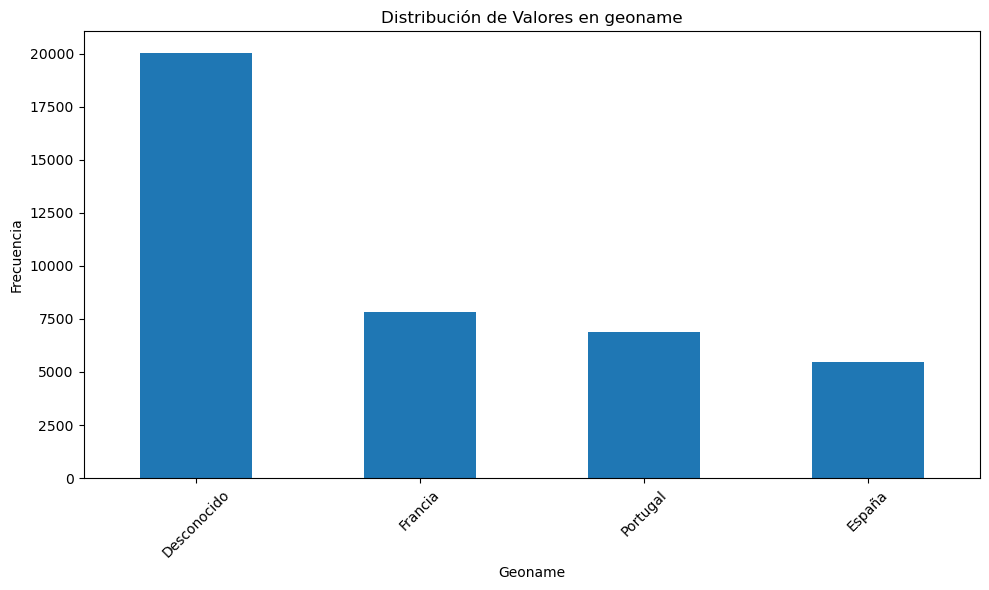

In [ ]:
geoname_counts = df['geoname'].value_counts()

plt.figure(figsize=(10, 6))
geoname_counts.plot(kind='bar')
plt.title('Distribución de Valores en geoname')
plt.xlabel('Geoname')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

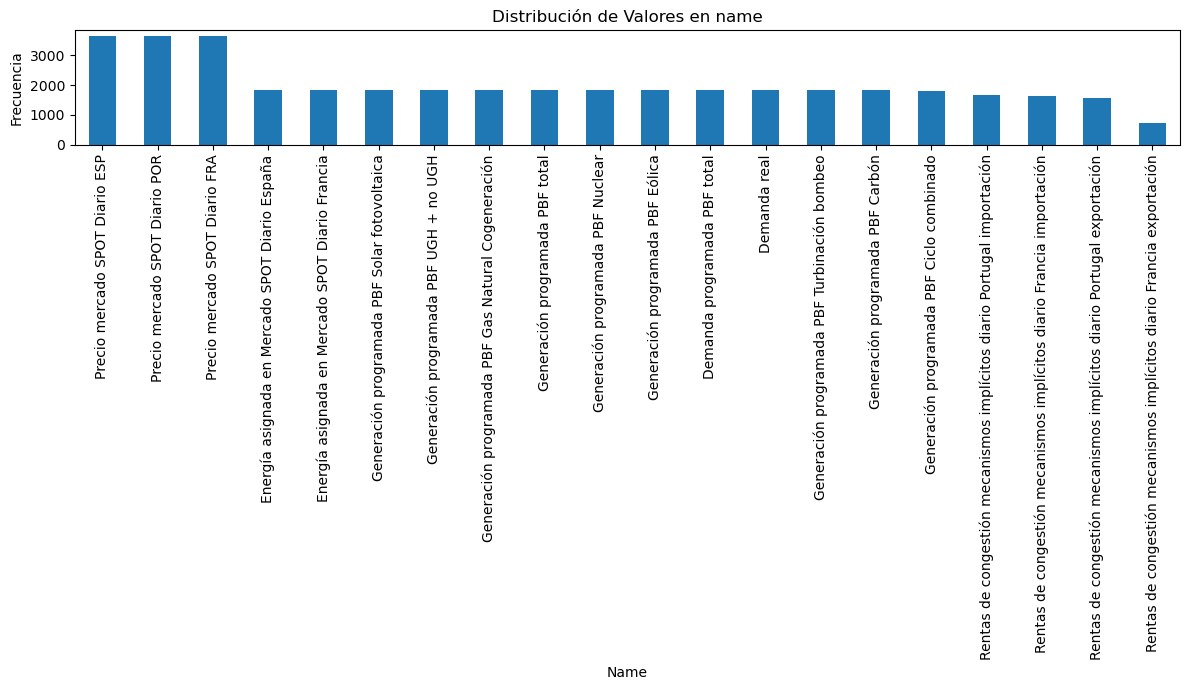

In [ ]:
name_counts = df['name'].value_counts()

plt.figure(figsize=(12, 7))
name_counts.plot(kind='bar')
plt.title('Distribución de Valores en name')
plt.xlabel('Name')
plt.ylabel('Frecuencia')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

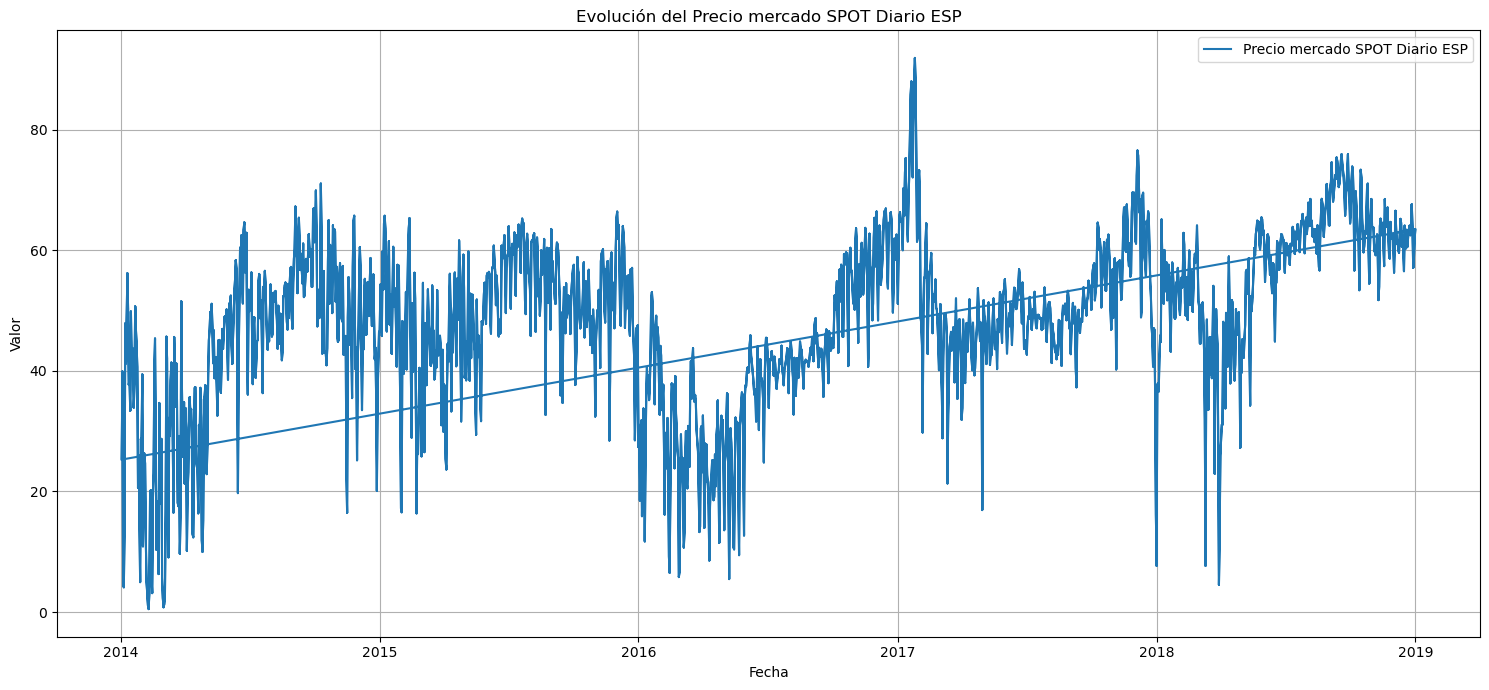

In [ ]:
df_esp = df[df['name'] == 'Precio mercado SPOT Diario ESP']

plt.figure(figsize=(15, 7))
plt.plot(df_esp['datetime'], df_esp['value'], label='Precio mercado SPOT Diario ESP')
plt.title('Evolución del Precio mercado SPOT Diario ESP')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

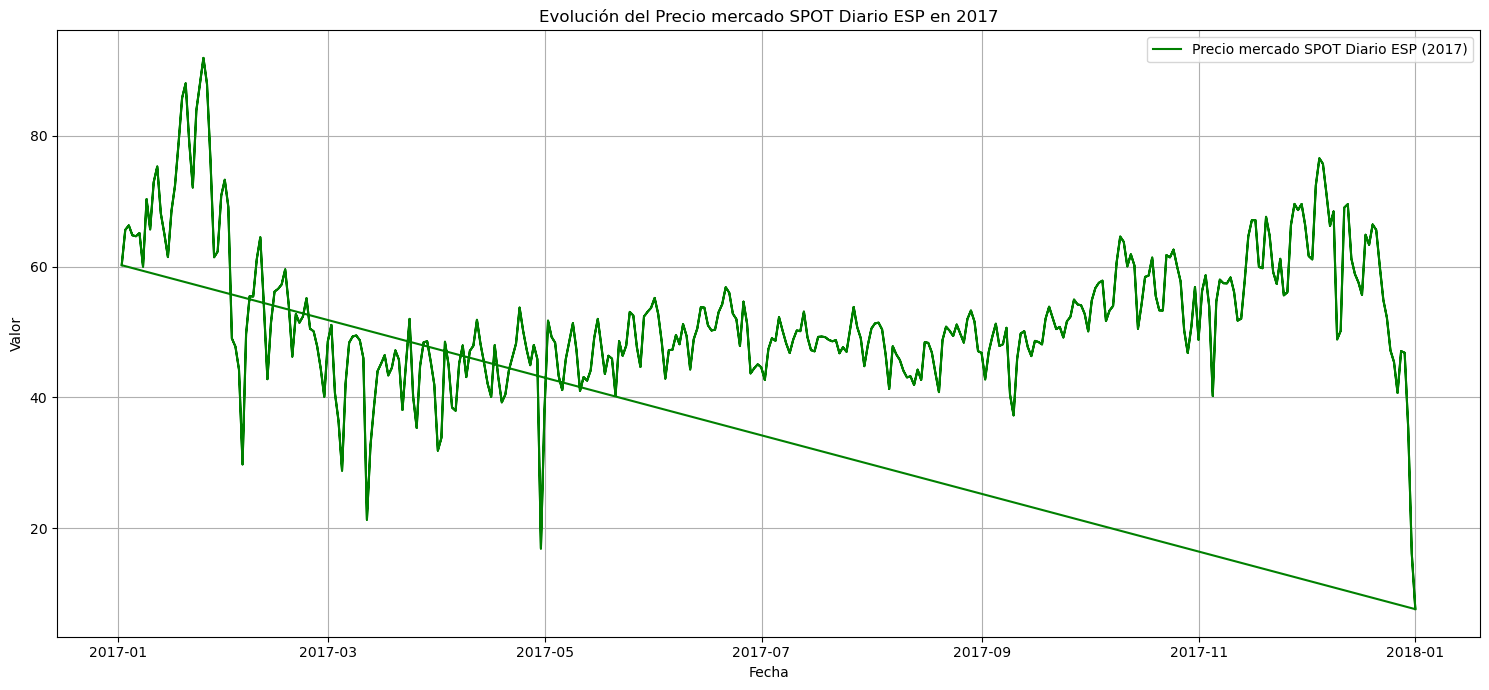

In [ ]:
df_esp_2017 = df_esp[(df_esp['datetime'].dt.year == 2017)]

plt.figure(figsize=(15, 7))
plt.plot(df_esp_2017['datetime'], df_esp_2017['value'], label='Precio mercado SPOT Diario ESP (2017)', color='green')
plt.title('Evolución del Precio mercado SPOT Diario ESP en 2017')
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"First Quartile (Q1): {Q1}")
print(f"Third Quartile (Q3): {Q3}")
print(f"Interquartile Range (IQR): {IQR}")
print(f"Upper Bound for Outliers: {upper_bound}")
print(f"Lower Bound for Outliers: {lower_bound}")

First Quartile (Q1): 51.12708333333333
Third Quartile (Q3): 161539.94999999998
Interquartile Range (IQR): 161488.82291666666
Upper Bound for Outliers: 403773.18437499995
Lower Bound for Outliers: -242182.10729166667


In [ ]:
outliers = df[(df['value'] < lower_bound) | (df['value'] > upper_bound)]
print(f"Number of outliers detected: {len(outliers)}")
print("First 5 outliers:")
print(outliers.head())

Number of outliers detected: 5741
First 5 outliers:
                datetime   id                                            name  \
5478 2014-01-01 23:00:00  602  Energía asignada en Mercado SPOT Diario España   
5479 2014-01-02 23:00:00  602  Energía asignada en Mercado SPOT Diario España   
5480 2014-01-03 23:00:00  602  Energía asignada en Mercado SPOT Diario España   
5481 2014-01-04 23:00:00  602  Energía asignada en Mercado SPOT Diario España   
5482 2014-01-05 23:00:00  602  Energía asignada en Mercado SPOT Diario España   

     geoid geoname     value        date      time  
5478     3  España  566081.9  2014-01-01  23:00:00  
5479     3  España  586355.6  2014-01-02  23:00:00  
5480     3  España  609612.9  2014-01-03  23:00:00  
5481     3  España  605090.0  2014-01-04  23:00:00  
5482     3  España  531020.2  2014-01-05  23:00:00  


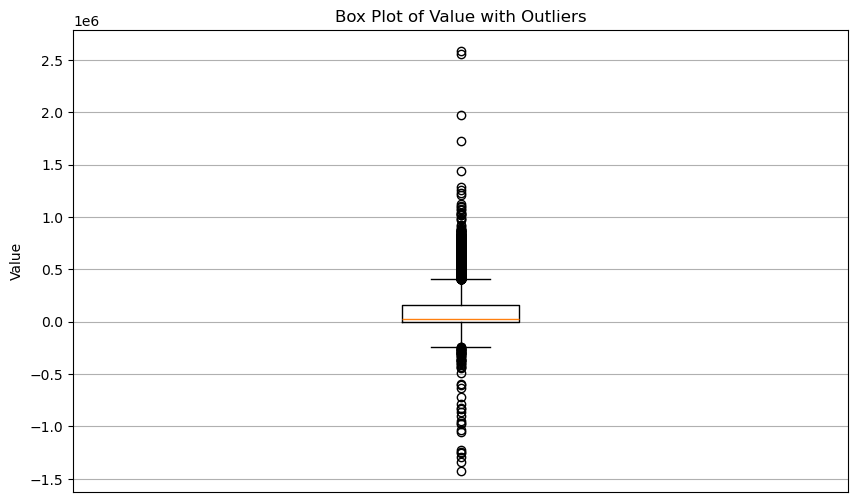

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(df['value'])
plt.title('Box Plot of Value with Outliers')
plt.ylabel('Value')
plt.xticks([]) # Hide x-axis ticks as it's a single box plot
plt.grid(True)
plt.show()

In [ ]:
df['year'] = df['datetime'].dt.year
print(df.head())

             datetime   id                            name geoid geoname  \
0 2014-01-01 23:00:00  600  Precio mercado SPOT Diario ESP     3  España   
1 2014-01-02 23:00:00  600  Precio mercado SPOT Diario ESP     3  España   
2 2014-01-03 23:00:00  600  Precio mercado SPOT Diario ESP     3  España   
3 2014-01-04 23:00:00  600  Precio mercado SPOT Diario ESP     3  España   
4 2014-01-05 23:00:00  600  Precio mercado SPOT Diario ESP     3  España   

       value        date      time  year  
0  25.280833  2014-01-01  23:00:00  2014  
1  39.924167  2014-01-02  23:00:00  2014  
2   4.992083  2014-01-03  23:00:00  2014  
3   4.091667  2014-01-04  23:00:00  2014  
4  13.587500  2014-01-05  23:00:00  2014  


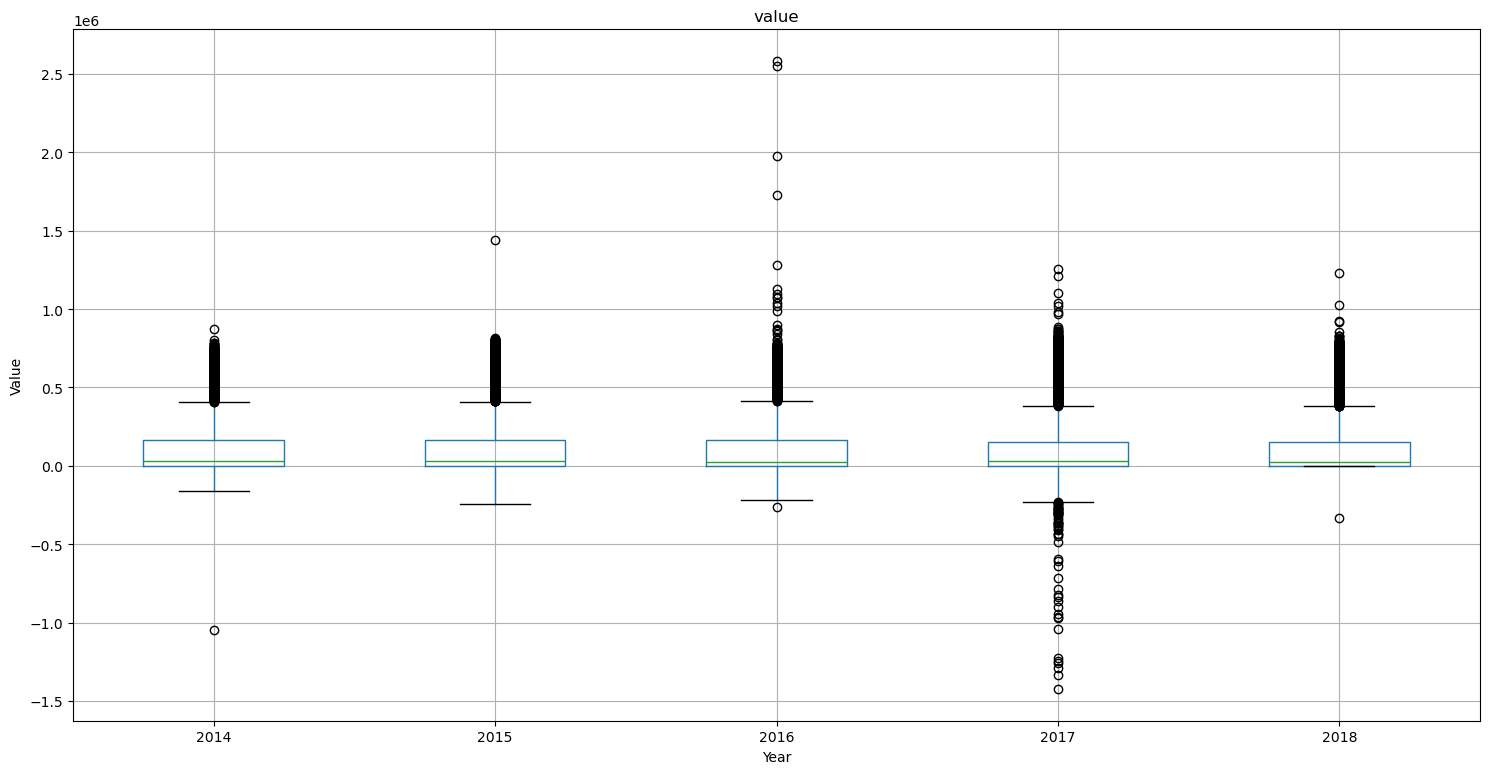

In [ ]:
plt.figure(figsize=(15, 8))
df.boxplot(column='value', by='year', ax=plt.gca())
plt.xlabel('Year')
plt.ylabel('Value')
plt.suptitle('') # Suppress the default suptitle created by boxplot when 'by' is used
plt.tight_layout()
plt.show()

In [ ]:
def analizar_outliers(df, columna='value'):
    """
    Analiza los outliers para entender qué son
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 3 * IQR
    outliers = df[df[columna] > limite_superior]

    print("=" * 60)
    print("ANÁLISIS DE OUTLIERS EXTREMOS")
    print("=" * 60)
    print(f"\nTotal outliers extremos: {len(outliers)}")

    if 'name' in outliers.columns:
        print("\nDistribución por tipo (name):")
        print(outliers['name'].value_counts().head(10))

    if 'geoname' in outliers.columns:
        print("\nDistribución por país:")
        print(outliers['geoname'].value_counts())

    if 'Year' in outliers.columns or 'year' in outliers.columns:
        year_col = 'Year' if 'Year' in outliers.columns else 'year'
        print(f"\nDistribución por año:")
        print(outliers[year_col].value_counts().sort_index())

    print(f"\nEstadísticas de outliers:")
    print(outliers[columna].describe())

    return outliers

outliers = analizar_outliers(df, columna='value')


ANÁLISIS DE OUTLIERS EXTREMOS

Total outliers extremos: 2268

Distribución por tipo (name):
name
Demanda programada PBF total                                              1174
Generación programada PBF total                                            972
Rentas de congestión mecanismos implícitos diario Francia importación       53
Energía asignada en Mercado SPOT Diario España                              46
Rentas de congestión mecanismos implícitos diario Francia exportación       21
Rentas de congestión mecanismos implícitos diario Portugal exportación       1
Rentas de congestión mecanismos implícitos diario Portugal importación       1
Name: count, dtype: int64

Distribución por país:
geoname
Desconocido    2146
Francia          74
España           46
Portugal          2
Name: count, dtype: int64

Distribución por año:
year
2014    381
2015    483
2016    482
2017    496
2018    426
Name: count, dtype: int64

Estadísticas de outliers:
count    2.268000e+03
mean     7.070199e+05
s

CATEGORÍAS DE VARIABLES

Precios:
  Registros: 10,956
  Rango: [0, 126]
  Media: 46
  Mediana: 47

Comercio/Asignación:
  Registros: 9,213
  Rango: [-1,426,133, 2,584,390]
  Media: 192,689
  Mediana: 121,627

Demanda:
  Registros: 1,825
  Rango: [21,197, 35,306]
  Media: 28,506
  Mediana: 28,513

Totales (Demanda/Generación):
  Registros: 3,650
  Rango: [457,838, 875,595]
  Media: 655,502
  Mediana: 659,190

Generación por fuente:
  Registros: 14,568
  Rango: [36, 398,630]
  Media: 76,306
  Mediana: 65,883


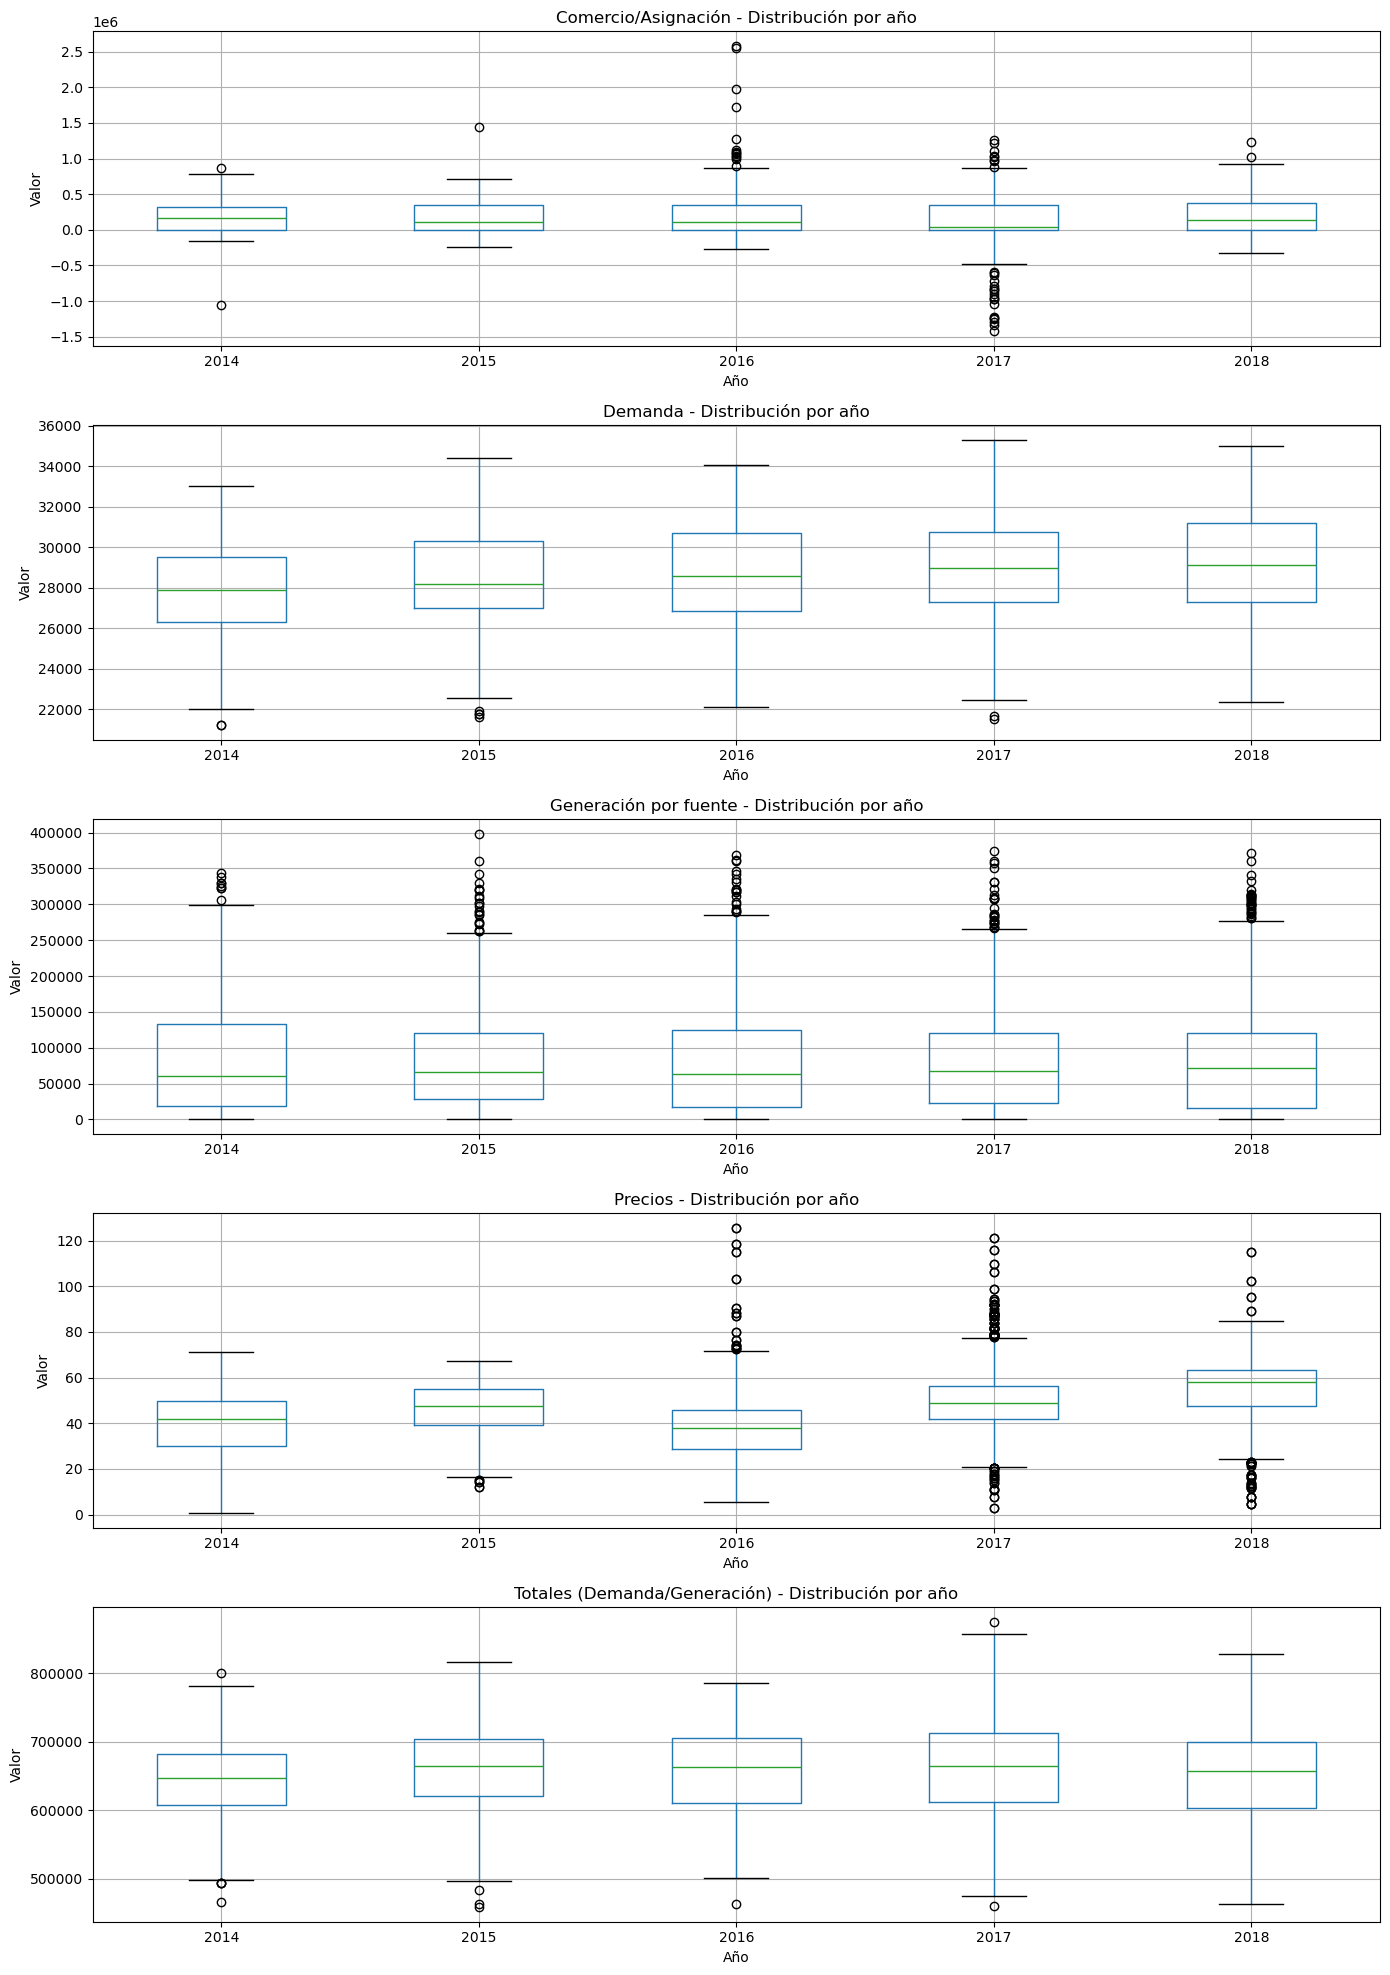

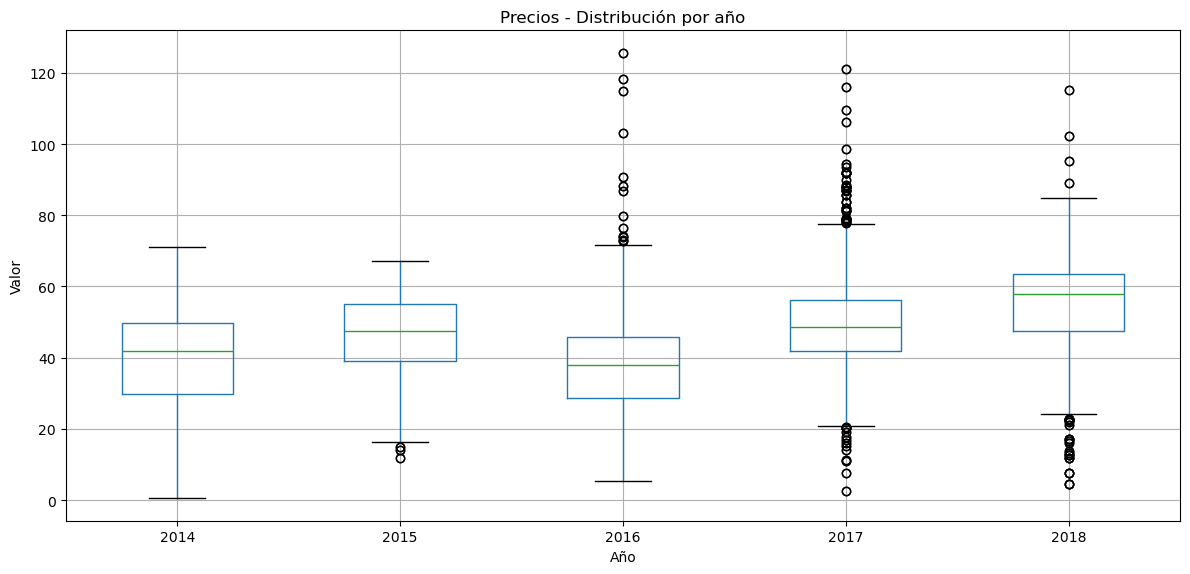


Estadísticas de Precios:
count    10956.000000
mean        45.908734
std         14.774716
min          0.477917
25%         36.514583
50%         46.720417
75%         56.300000
max        125.673333
Name: value, dtype: float64


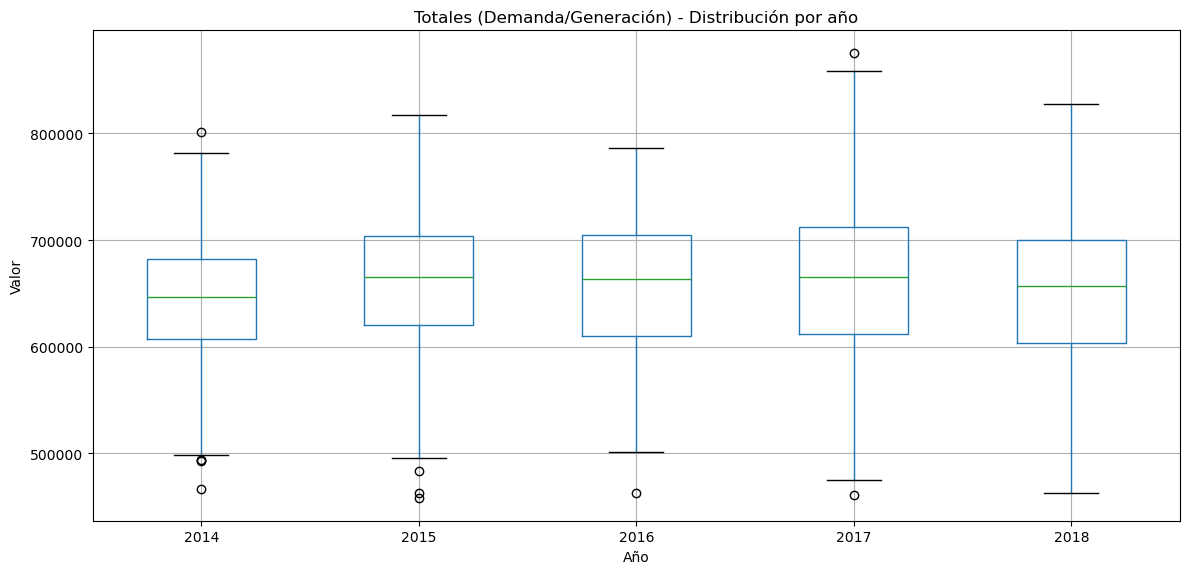


Estadísticas de Totales (Demanda/Generación):
count      3650.000000
mean     655501.569945
std       66479.746781
min      457837.600000
25%      610301.300000
50%      659189.950000
75%      699161.825000
max      875595.100000
Name: value, dtype: float64


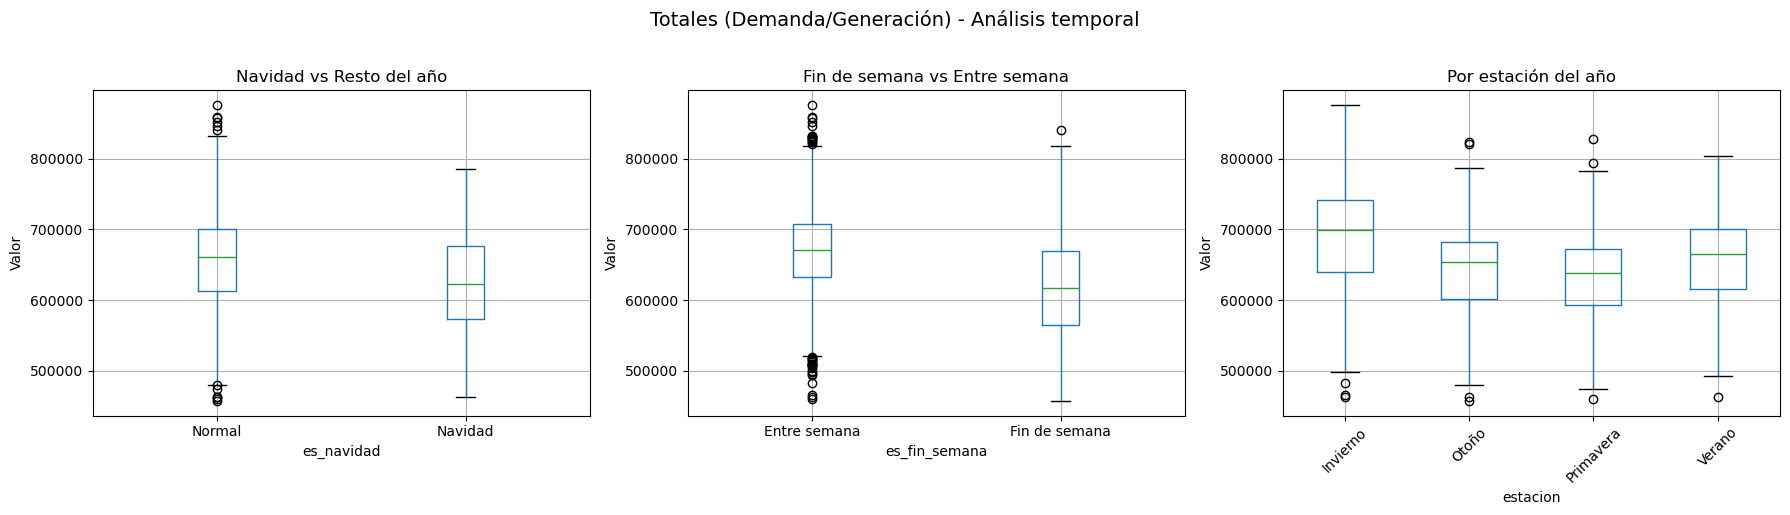

ANÁLISIS TEMPORAL - Totales (Demanda/Generación)

Navidad vs Normal:
             count           mean           std       min         25%  \
es_navidad                                                              
False       3462.0  657188.905748  66136.663146  457837.6  612572.450   
True         188.0  624429.460638  65283.458107  463137.8  573728.475   

                 50%        75%       max  
es_navidad                                 
False       660838.7  700868.75  875595.1  
True        623405.2  675898.95  785307.2  

Fin de semana vs Entre semana:
                count           mean           std       min        25%  \
es_fin_semana                                                             
False          2606.0  669424.831811  60220.695186  460587.2  632559.05   
True           1044.0  620746.761111  68636.984742  457837.6  565491.10   

                    50%       75%       max  
es_fin_semana                                
False          670323.2  707847.8  87

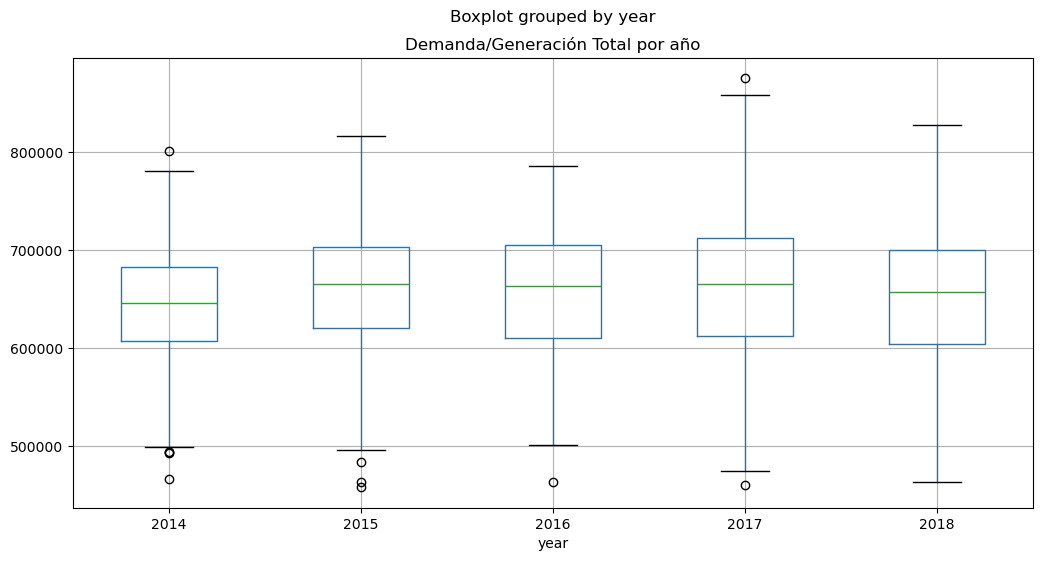

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# CLASIFICAR VARIABLES POR CATEGORÍA
# ============================================
def clasificar_variable(name):
    """
    Clasifica las variables en categorías según su naturaleza
    """
    if pd.isna(name):
        return 'Otros'

    name_lower = name.lower()

    # Totales (demanda/generación total)
    if 'total' in name_lower and ('demanda' in name_lower or 'generación' in name_lower):
        return 'Totales (Demanda/Generación)'

    # Precios
    if 'precio' in name_lower or 'price' in name_lower:
        return 'Precios'

    # Energía asignada / comercio
    if 'asignada' in name_lower or 'renta' in name_lower or 'congestión' in name_lower:
        return 'Comercio/Asignación'

    # Generación por fuente
    if 'generación' in name_lower or 'producción' in name_lower:
        return 'Generación por fuente'

    # Demanda
    if 'demanda' in name_lower:
        return 'Demanda'

    return 'Otros'


def analizar_categorias(df):
    """
    Analiza las categorías de variables
    """
    df['categoria'] = df['name'].apply(clasificar_variable)

    print("=" * 70)
    print("CATEGORÍAS DE VARIABLES")
    print("=" * 70)

    for categoria in df['categoria'].unique():
        datos = df[df['categoria'] == categoria]['value']
        count = len(datos)
        print(f"\n{categoria}:")
        print(f"  Registros: {count:,}")
        print(f"  Rango: [{datos.min():,.0f}, {datos.max():,.0f}]")
        print(f"  Media: {datos.mean():,.0f}")
        print(f"  Mediana: {datos.median():,.0f}")

    return df


# ============================================
# BOXPLOT POR CATEGORÍA Y AÑO
# ============================================
def boxplot_por_categoria(df, categoria=None, mostrar_todas=False):
    """
    Crea boxplots separados por categoría de variable
    """
    if 'categoria' not in df.columns:
        df['categoria'] = df['name'].apply(clasificar_variable)

    if mostrar_todas:
        # Mostrar todas las categorías en subplots
        categorias = df['categoria'].unique()
        n_cats = len(categorias)

        fig, axes = plt.subplots(n_cats, 1, figsize=(14, 4*n_cats))
        if n_cats == 1:
            axes = [axes]

        for idx, cat in enumerate(sorted(categorias)):
            df_cat = df[df['categoria'] == cat]
            df_cat.boxplot(column='value', by='year', ax=axes[idx])
            axes[idx].set_title(f'{cat} - Distribución por año')
            axes[idx].set_xlabel('Año')
            axes[idx].set_ylabel('Valor')

        plt.suptitle('')
        plt.tight_layout()
        plt.show()

    elif categoria:
        # Mostrar solo una categoría
        df_cat = df[df['categoria'] == categoria]

        fig, ax = plt.subplots(figsize=(12, 6))
        df_cat.boxplot(column='value', by='year', ax=ax)
        ax.set_title(f'{categoria} - Distribución por año')
        ax.set_xlabel('Año')
        ax.set_ylabel('Valor')
        plt.suptitle('')
        plt.tight_layout()
        plt.show()

        print(f"\nEstadísticas de {categoria}:")
        print(df_cat['value'].describe())

    else:
        print("Especifica una categoría o usa mostrar_todas=True")
        print(f"Categorías disponibles: {df['categoria'].unique()}")


# ============================================
# ANÁLISIS TEMPORAL (Festivos, estacionalidad)
# ============================================
def analizar_temporalidad(df):
    """
    Analiza patrones temporales: festivos, estaciones, días de la semana
    """
    df = df.copy()

    # Asegurar que datetime es tipo datetime
    if not pd.api.types.is_datetime64_any_dtype(df['datetime']):
        df['datetime'] = pd.to_datetime(df['datetime'])

    # Extraer características temporales
    df['mes'] = df['datetime'].dt.month
    df['dia_semana'] = df['datetime'].dt.dayofweek  # 0=Lunes, 6=Domingo
    df['dia_mes'] = df['datetime'].dt.day
    df['trimestre'] = df['datetime'].dt.quarter

    # Clasificar estaciones
    def get_estacion(mes):
        if mes in [12, 1, 2]:
            return 'Invierno'
        elif mes in [3, 4, 5]:
            return 'Primavera'
        elif mes in [6, 7, 8]:
            return 'Verano'
        else:
            return 'Otoño'

    df['estacion'] = df['mes'].apply(get_estacion)

    # Identificar festivos aproximados (Navidad, Año Nuevo)
    df['es_navidad'] = ((df['mes'] == 12) & (df['dia_mes'].between(20, 31))) | \
                       ((df['mes'] == 1) & (df['dia_mes'].between(1, 7)))

    df['es_fin_semana'] = df['dia_semana'].isin([5, 6])  # Sábado, Domingo

    return df


def comparar_festivos_vs_normal(df, categoria='Totales (Demanda/Generación)'):
    """
    Compara valores en períodos festivos vs normales
    """
    df = analizar_temporalidad(df)

    if 'categoria' not in df.columns:
        df['categoria'] = df['name'].apply(clasificar_variable)

    df_cat = df[df['categoria'] == categoria]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Comparación: Navidad vs resto
    df_cat.boxplot(column='value', by='es_navidad', ax=axes[0])
    axes[0].set_title('Navidad vs Resto del año')
    axes[0].set_xticklabels(['Normal', 'Navidad'])
    axes[0].set_ylabel('Valor')

    # Comparación: Fin de semana vs entre semana
    df_cat.boxplot(column='value', by='es_fin_semana', ax=axes[1])
    axes[1].set_title('Fin de semana vs Entre semana')
    axes[1].set_xticklabels(['Entre semana', 'Fin de semana'])
    axes[1].set_ylabel('Valor')

    # Por estación
    df_cat.boxplot(column='value', by='estacion', ax=axes[2])
    axes[2].set_title('Por estación del año')
    axes[2].set_ylabel('Valor')
    axes[2].tick_params(axis='x', rotation=45)

    plt.suptitle(f'{categoria} - Análisis temporal', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Estadísticas
    print("=" * 70)
    print(f"ANÁLISIS TEMPORAL - {categoria}")
    print("=" * 70)

    print("\nNavidad vs Normal:")
    print(df_cat.groupby('es_navidad')['value'].describe())

    print("\nFin de semana vs Entre semana:")
    print(df_cat.groupby('es_fin_semana')['value'].describe())

    print("\nPor estación:")
    print(df_cat.groupby('estacion')['value'].describe())


# ============================================
# EJEMPLO DE USO COMPLETO
# ============================================

# 1. Clasificar y analizar categorías
df = analizar_categorias(df)

# 2. Ver boxplot de todas las categorías separadas
boxplot_por_categoria(df, mostrar_todas=True)

# 3. Ver solo una categoría específica
boxplot_por_categoria(df, categoria='Precios')
boxplot_por_categoria(df, categoria='Totales (Demanda/Generación)')

# 4. Analizar temporalidad (festivos, estaciones)
comparar_festivos_vs_normal(df, categoria='Totales (Demanda/Generación)')

# 5. Para demanda/generación específicamente
df_demanda = df[df['categoria'] == 'Totales (Demanda/Generación)']
df_demanda.boxplot(column='value', by='year', figsize=(12, 6))
plt.title('Demanda/Generación Total por año')
plt.show()


📊 Hallazgos clave:


🎄 Navidad (20 dic - 7 ene):

Media Normal: 657,189 vs Navidad: 624,429 ⬇️ 5% menos
Durante las festividades la demanda baja significativamente (empresas cerradas, industria parada)

📅 Fin de semana:

Entre semana: 669,425 vs Fin de semana: 620,747 ⬇️ 7% menos
El patrón más fuerte: los fines de semana tienen mucho menos consumo industrial

🌡️ Por estación:

Invierno: 689,434 (máximo) ❄️ - Calefacción
Verano: 658,139 ☀️ - Aire acondicionado
Otoño: 642,959 🍂
Primavera: 632,077 (mínimo) 🌸 - Clima templado

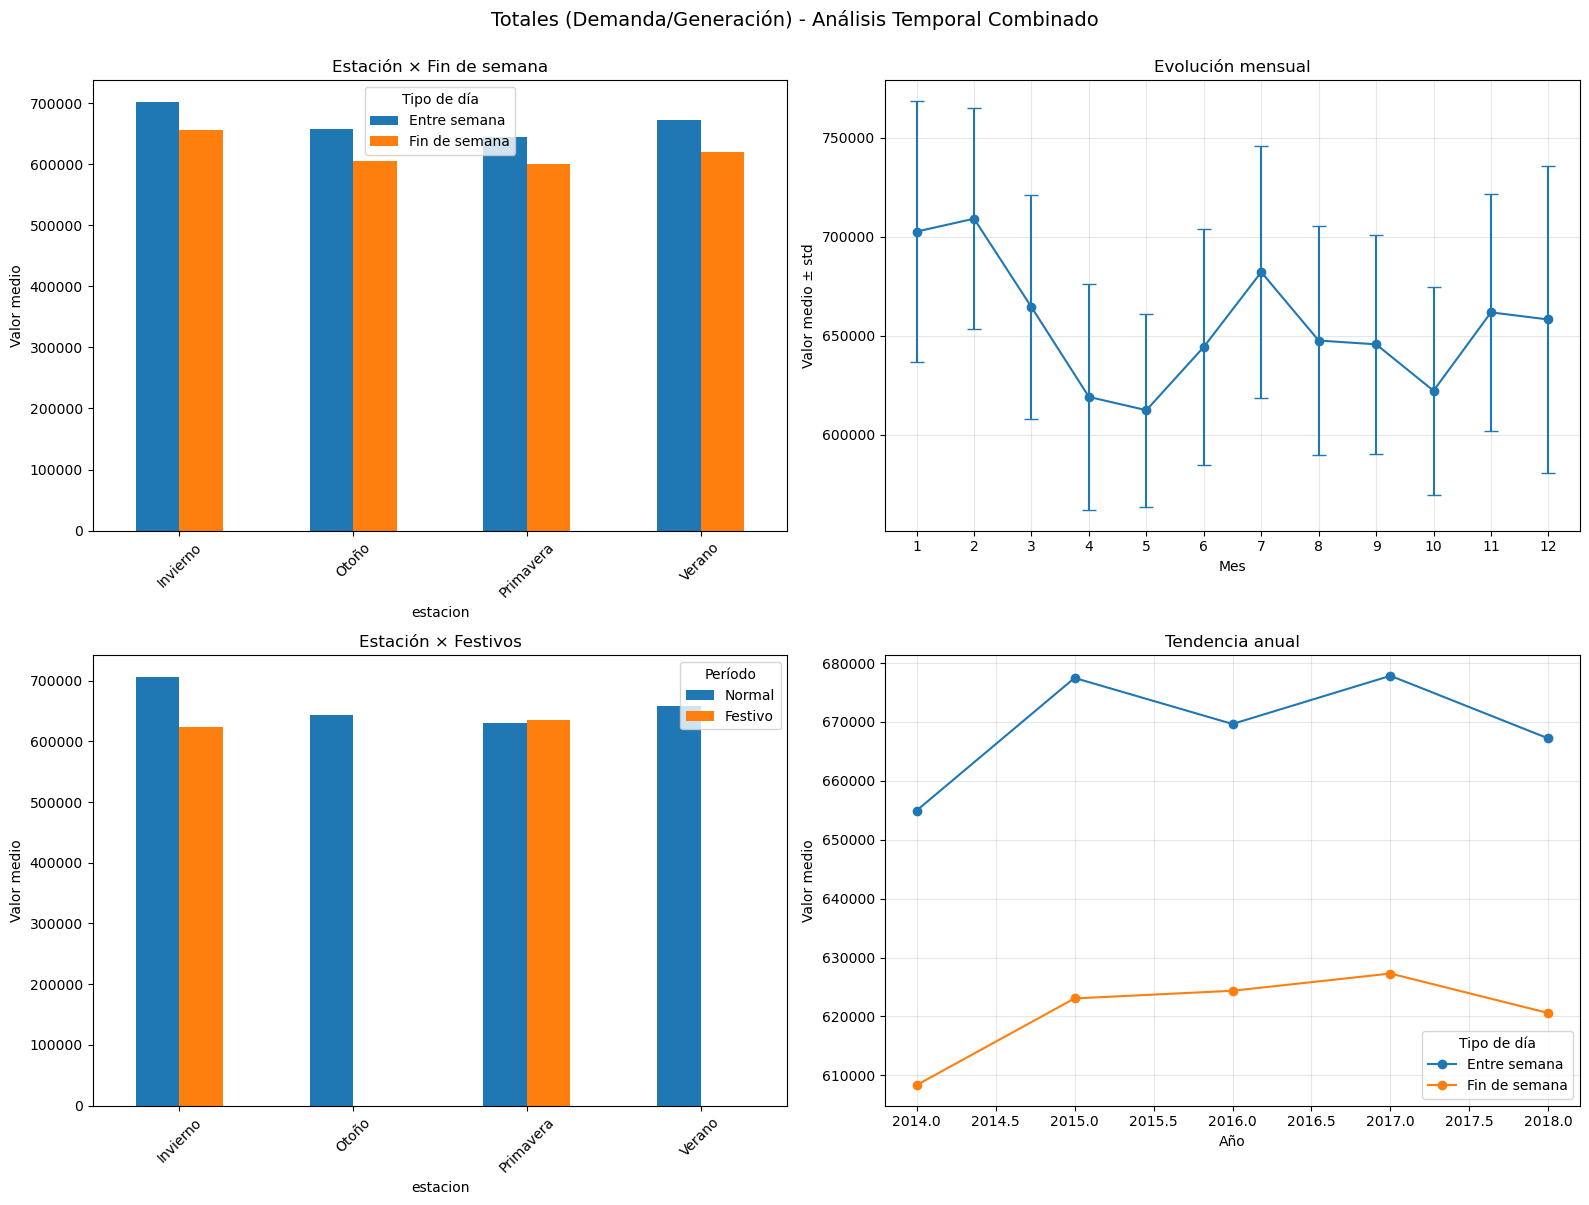

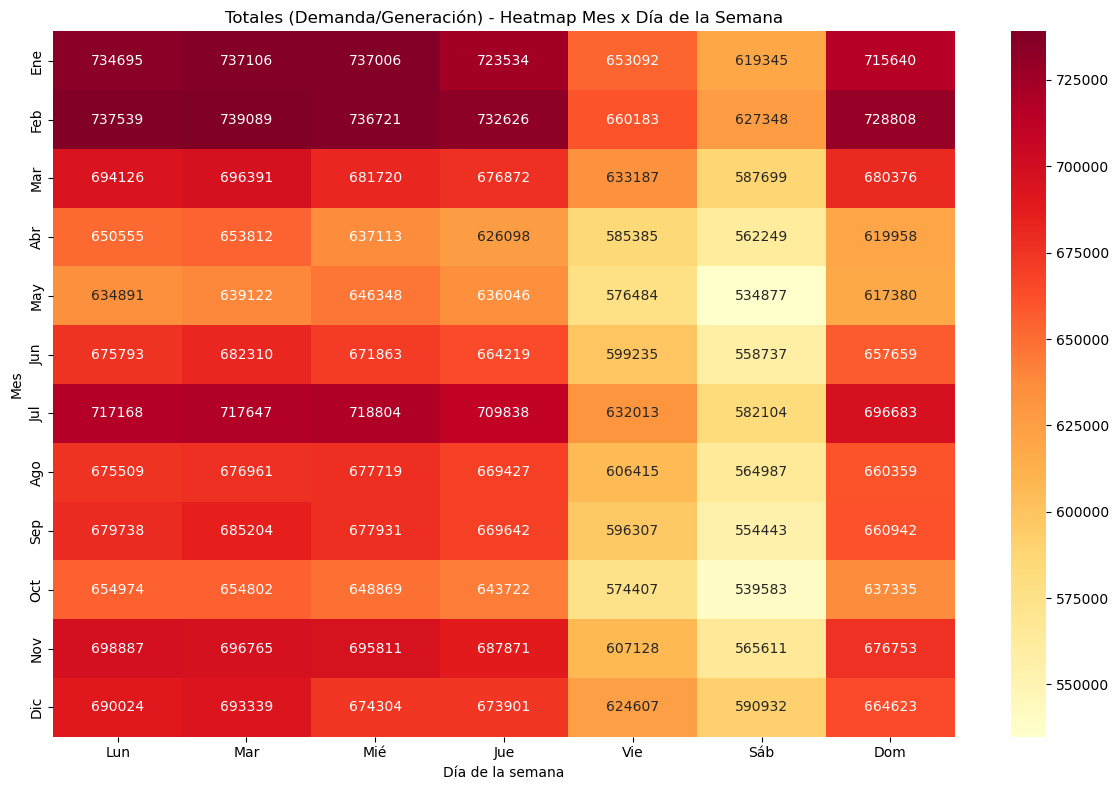

PERFILES DE CONSUMO - Totales (Demanda/Generación)

        Perfil  Registros         Media   Mediana          Std      Min      Max
  Pico consumo        642 702614.211994 713252.90 66666.613323 463137.8 875595.1
        Agosto        310 647535.645484 657625.60 57882.734834 506062.3 757853.6
  Semana Santa        350 634860.761714 642819.10 62033.998607 460587.2 827873.5
       Navidad        188 624429.460638 623405.20 65283.458107 463137.8 785307.2
Mínimo consumo        264 600423.075758 595478.65 59851.708724 474651.8 741475.1

DIFERENCIAS PORCENTUALES respecto al MÍNIMO

        Perfil         Media  Diferencia %
  Pico consumo 702614.211994         17.02
        Agosto 647535.645484          7.85
  Semana Santa 634860.761714          5.74
       Navidad 624429.460638          4.00
Mínimo consumo 600423.075758          0.00


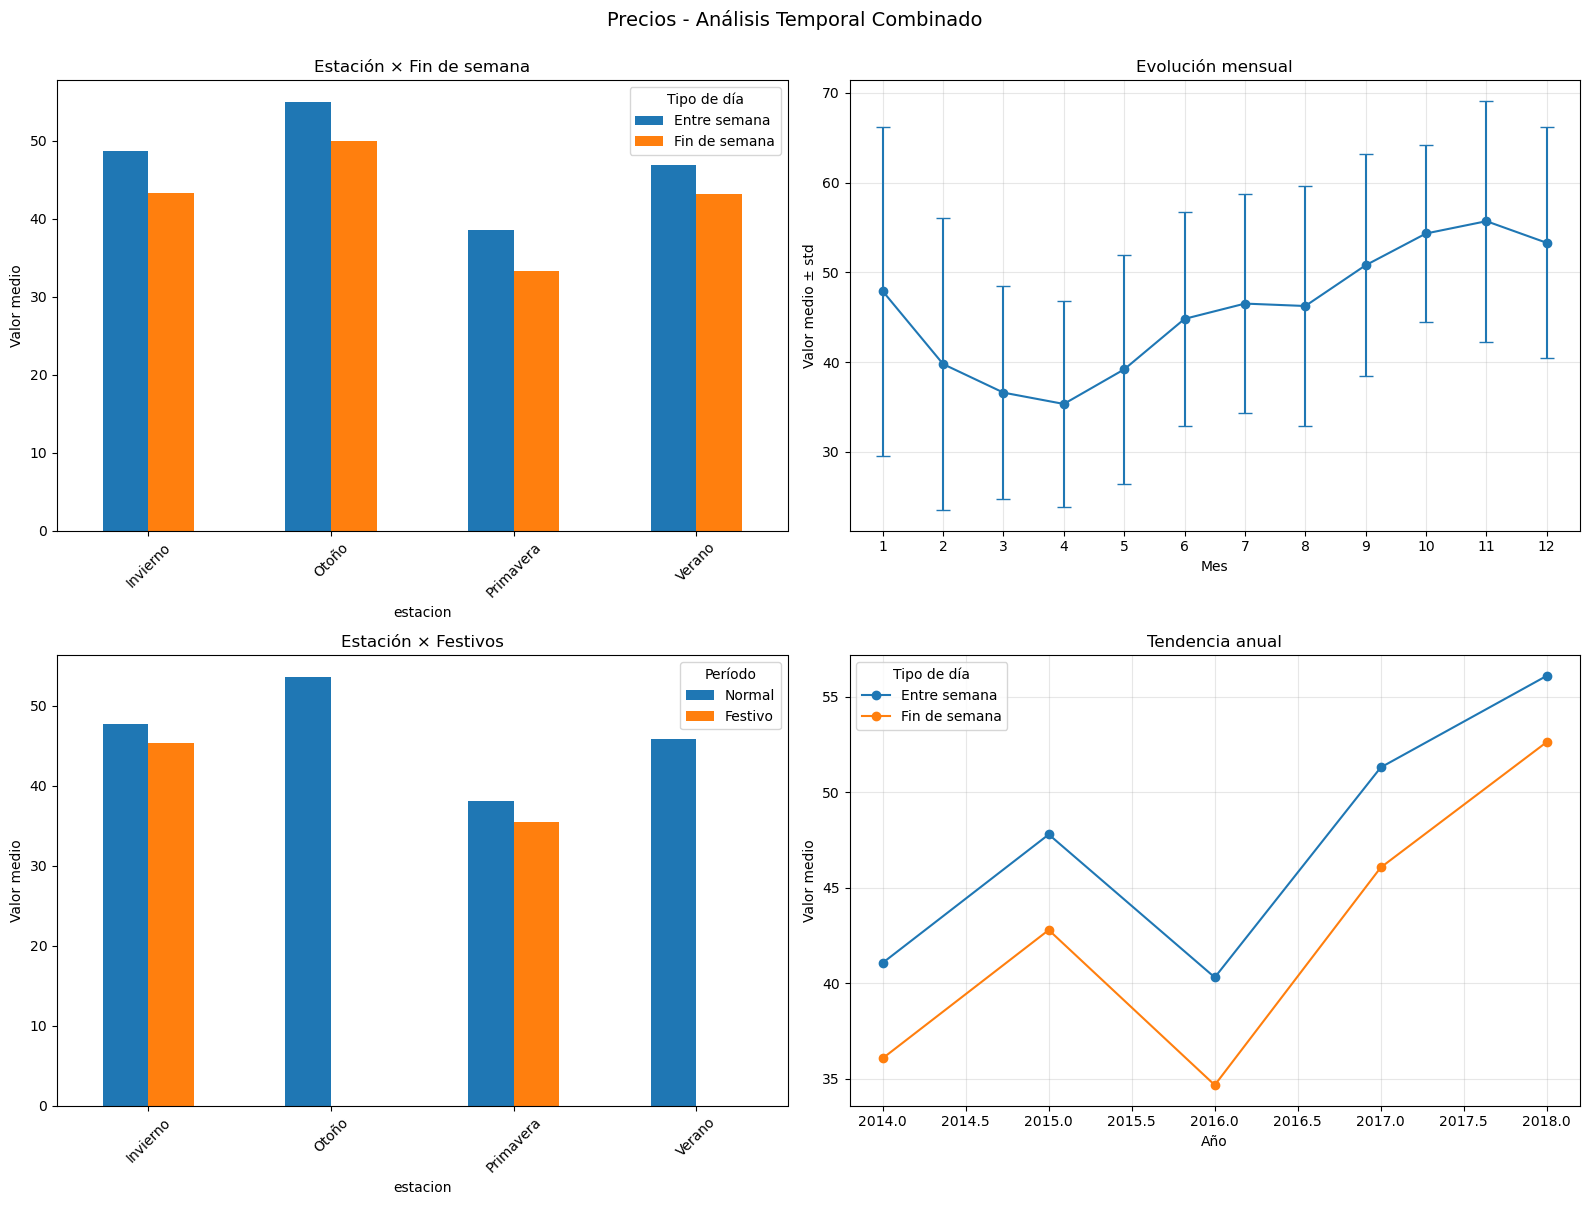

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def crear_features_temporales_avanzadas(df):
    """
    Crea features temporales más detalladas
    """
    df = df.copy()

    if not pd.api.types.is_datetime64_any_dtype(df['datetime']):
        df['datetime'] = pd.to_datetime(df['datetime'])

    # Features básicas
    df['year'] = df['datetime'].dt.year
    df['mes'] = df['datetime'].dt.month
    df['dia_semana'] = df['datetime'].dt.dayofweek
    df['dia_mes'] = df['datetime'].dt.day
    df['semana_año'] = df['datetime'].dt.isocalendar().week

    # Clasificaciones
    df['es_fin_semana'] = df['dia_semana'].isin([5, 6])

    # Festivos importantes en España
    df['es_navidad'] = ((df['mes'] == 12) & (df['dia_mes'].between(20, 31))) | \
                       ((df['mes'] == 1) & (df['dia_mes'].between(1, 7)))

    df['es_semana_santa'] = ((df['mes'] == 3) | (df['mes'] == 4)) & \
                            (df['semana_año'].between(12, 16))  # Aproximado

    df['es_agosto'] = (df['mes'] == 8)  # Vacaciones verano

    df['es_festivo_especial'] = df['es_navidad'] | df['es_semana_santa']

    # Estación
    def get_estacion(mes):
        if mes in [12, 1, 2]:
            return 'Invierno'
        elif mes in [3, 4, 5]:
            return 'Primavera'
        elif mes in [6, 7, 8]:
            return 'Verano'
        else:
            return 'Otoño'

    df['estacion'] = df['mes'].apply(get_estacion)

    # Hora del día (si está disponible)
    if 'time' in df.columns:
        df['hora'] = pd.to_datetime(df['time'], format='%H:%M:%S', errors='coerce').dt.hour
        df['periodo_dia'] = pd.cut(df['hora'],
                                   bins=[0, 6, 12, 18, 24],
                                   labels=['Madrugada', 'Mañana', 'Tarde', 'Noche'],
                                   include_lowest=True)

    return df


def heatmap_temporal(df, categoria='Totales (Demanda/Generación)'):
    """
    Crea un heatmap mes x día_semana para ver patrones
    """
    if 'categoria' not in df.columns:
        df['categoria'] = df['name'].apply(clasificar_variable)

    df = crear_features_temporales_avanzadas(df)
    df_cat = df[df['categoria'] == categoria]

    # Crear matriz mes x día de semana
    pivot = df_cat.pivot_table(values='value',
                               index='mes',
                               columns='dia_semana',
                               aggfunc='mean')

    # Nombres para ejes
    dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
    meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
             'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
                xticklabels=dias, yticklabels=meses)
    plt.title(f'{categoria} - Heatmap Mes x Día de la Semana')
    plt.xlabel('Día de la semana')
    plt.ylabel('Mes')
    plt.tight_layout()
    plt.show()


def comparacion_combinada(df, categoria='Totales (Demanda/Generación)'):
    """
    Compara combinaciones de factores temporales
    """
    if 'categoria' not in df.columns:
        df['categoria'] = df['name'].apply(clasificar_variable)

    df = crear_features_temporales_avanzadas(df)
    df_cat = df[df['categoria'] == categoria]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Estación x Fin de semana
    pivot1 = df_cat.pivot_table(values='value',
                                index='estacion',
                                columns='es_fin_semana',
                                aggfunc='mean')
    pivot1.columns = ['Entre semana', 'Fin de semana']
    pivot1.plot(kind='bar', ax=axes[0, 0], rot=45)
    axes[0, 0].set_title('Estación × Fin de semana')
    axes[0, 0].set_ylabel('Valor medio')
    axes[0, 0].legend(title='Tipo de día')

    # 2. Mes del año
    monthly = df_cat.groupby('mes')['value'].agg(['mean', 'std'])
    axes[0, 1].errorbar(monthly.index, monthly['mean'],
                       yerr=monthly['std'], marker='o', capsize=5)
    axes[0, 1].set_title('Evolución mensual')
    axes[0, 1].set_xlabel('Mes')
    axes[0, 1].set_ylabel('Valor medio ± std')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xticks(range(1, 13))

    # 3. Festivos vs Normal × Estación
    pivot3 = df_cat.pivot_table(values='value',
                                index='estacion',
                                columns='es_festivo_especial',
                                aggfunc='mean')
    pivot3.columns = ['Normal', 'Festivo']
    pivot3.plot(kind='bar', ax=axes[1, 0], rot=45)
    axes[1, 0].set_title('Estación × Festivos')
    axes[1, 0].set_ylabel('Valor medio')
    axes[1, 0].legend(title='Período')

    # 4. Evolución año a año
    yearly = df_cat.groupby(['year', 'es_fin_semana'])['value'].mean().unstack()
    yearly.columns = ['Entre semana', 'Fin de semana']
    yearly.plot(kind='line', marker='o', ax=axes[1, 1])
    axes[1, 1].set_title('Tendencia anual')
    axes[1, 1].set_xlabel('Año')
    axes[1, 1].set_ylabel('Valor medio')
    axes[1, 1].legend(title='Tipo de día')
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'{categoria} - Análisis Temporal Combinado',
                 fontsize=14, y=1.00)
    plt.tight_layout()
    plt.show()


def estadisticas_por_perfil(df, categoria='Totales (Demanda/Generación)'):
    """
    Estadísticas detalladas por diferentes perfiles temporales
    """
    if 'categoria' not in df.columns:
        df['categoria'] = df['name'].apply(clasificar_variable)

    df = crear_features_temporales_avanzadas(df)
    df_cat = df[df['categoria'] == categoria]

    print("=" * 80)
    print(f"PERFILES DE CONSUMO - {categoria}")
    print("=" * 80)

    # Definir perfiles
    perfiles = {
        'Pico consumo': (df_cat['estacion'] == 'Invierno') & (~df_cat['es_fin_semana']),
        'Mínimo consumo': (df_cat['estacion'] == 'Primavera') & (df_cat['es_fin_semana']),
        'Navidad': df_cat['es_navidad'],
        'Agosto': df_cat['es_agosto'],
        'Semana Santa': df_cat['es_semana_santa']
    }

    resultados = []
    for nombre, condicion in perfiles.items():
        datos = df_cat[condicion]['value']
        if len(datos) > 0:
            resultados.append({
                'Perfil': nombre,
                'Registros': len(datos),
                'Media': datos.mean(),
                'Mediana': datos.median(),
                'Std': datos.std(),
                'Min': datos.min(),
                'Max': datos.max()
            })

    resultado_df = pd.DataFrame(resultados)
    resultado_df = resultado_df.sort_values('Media', ascending=False)

    print("\n" + resultado_df.to_string(index=False))

    # Calcular diferencias porcentuales
    print("\n" + "=" * 80)
    print("DIFERENCIAS PORCENTUALES respecto al MÍNIMO")
    print("=" * 80)

    minimo = resultado_df['Media'].min()
    resultado_df['Diferencia %'] = ((resultado_df['Media'] - minimo) / minimo * 100).round(2)
    print("\n" + resultado_df[['Perfil', 'Media', 'Diferencia %']].to_string(index=False))

    return resultado_df


# ============================================
# EJEMPLO DE USO
# ============================================

# 1. Análisis completo combinado
comparacion_combinada(df, categoria='Totales (Demanda/Generación)')

# 2. Heatmap para ver patrones
heatmap_temporal(df, categoria='Totales (Demanda/Generación)')

# 3. Estadísticas por perfil
stats = estadisticas_por_perfil(df, categoria='Totales (Demanda/Generación)')

# 4. Para otras categorías
comparacion_combinada(df, categoria='Precios')


🎯 Hallazgos clave:

📊 Diferencia Pico vs Mínimo: 17%

Pico: Invierno entre semana = 702,614 MWh

Mínimo: Primavera fin de semana = 600,423 MWh

Diferencia: 102,191 MWh (equivalente a la demanda de una ciudad mediana)

🎄 Impacto de Festivos:

Navidad: -4% vs mínimo = -11% vs consumo normal

Semana Santa: -5.7% vs mínimo = -9% vs consumo normal

Agosto: -7.8% vs mínimo = paradas industriales masivas

💡 Insights importantes:Agosto es crítico: Aunque no es "festivo oficial", tiene casi el doble de impacto que Navidad por las vacaciones industriales prolongadas.

Orden de consumo:
Invierno laboral (máx) → Agosto → Semana Santa → Navidad → Primavera fin de semana (mín)

Total de registros de precios: 10,956
Países: ['España' 'Portugal' 'Francia']
Tipos de precios: ['Precio mercado SPOT Diario ESP' 'Precio mercado SPOT Diario POR'
 'Precio mercado SPOT Diario FRA']
Rango temporal: 2014-01-01 23:00:00 a 2018-12-31 23:00:00


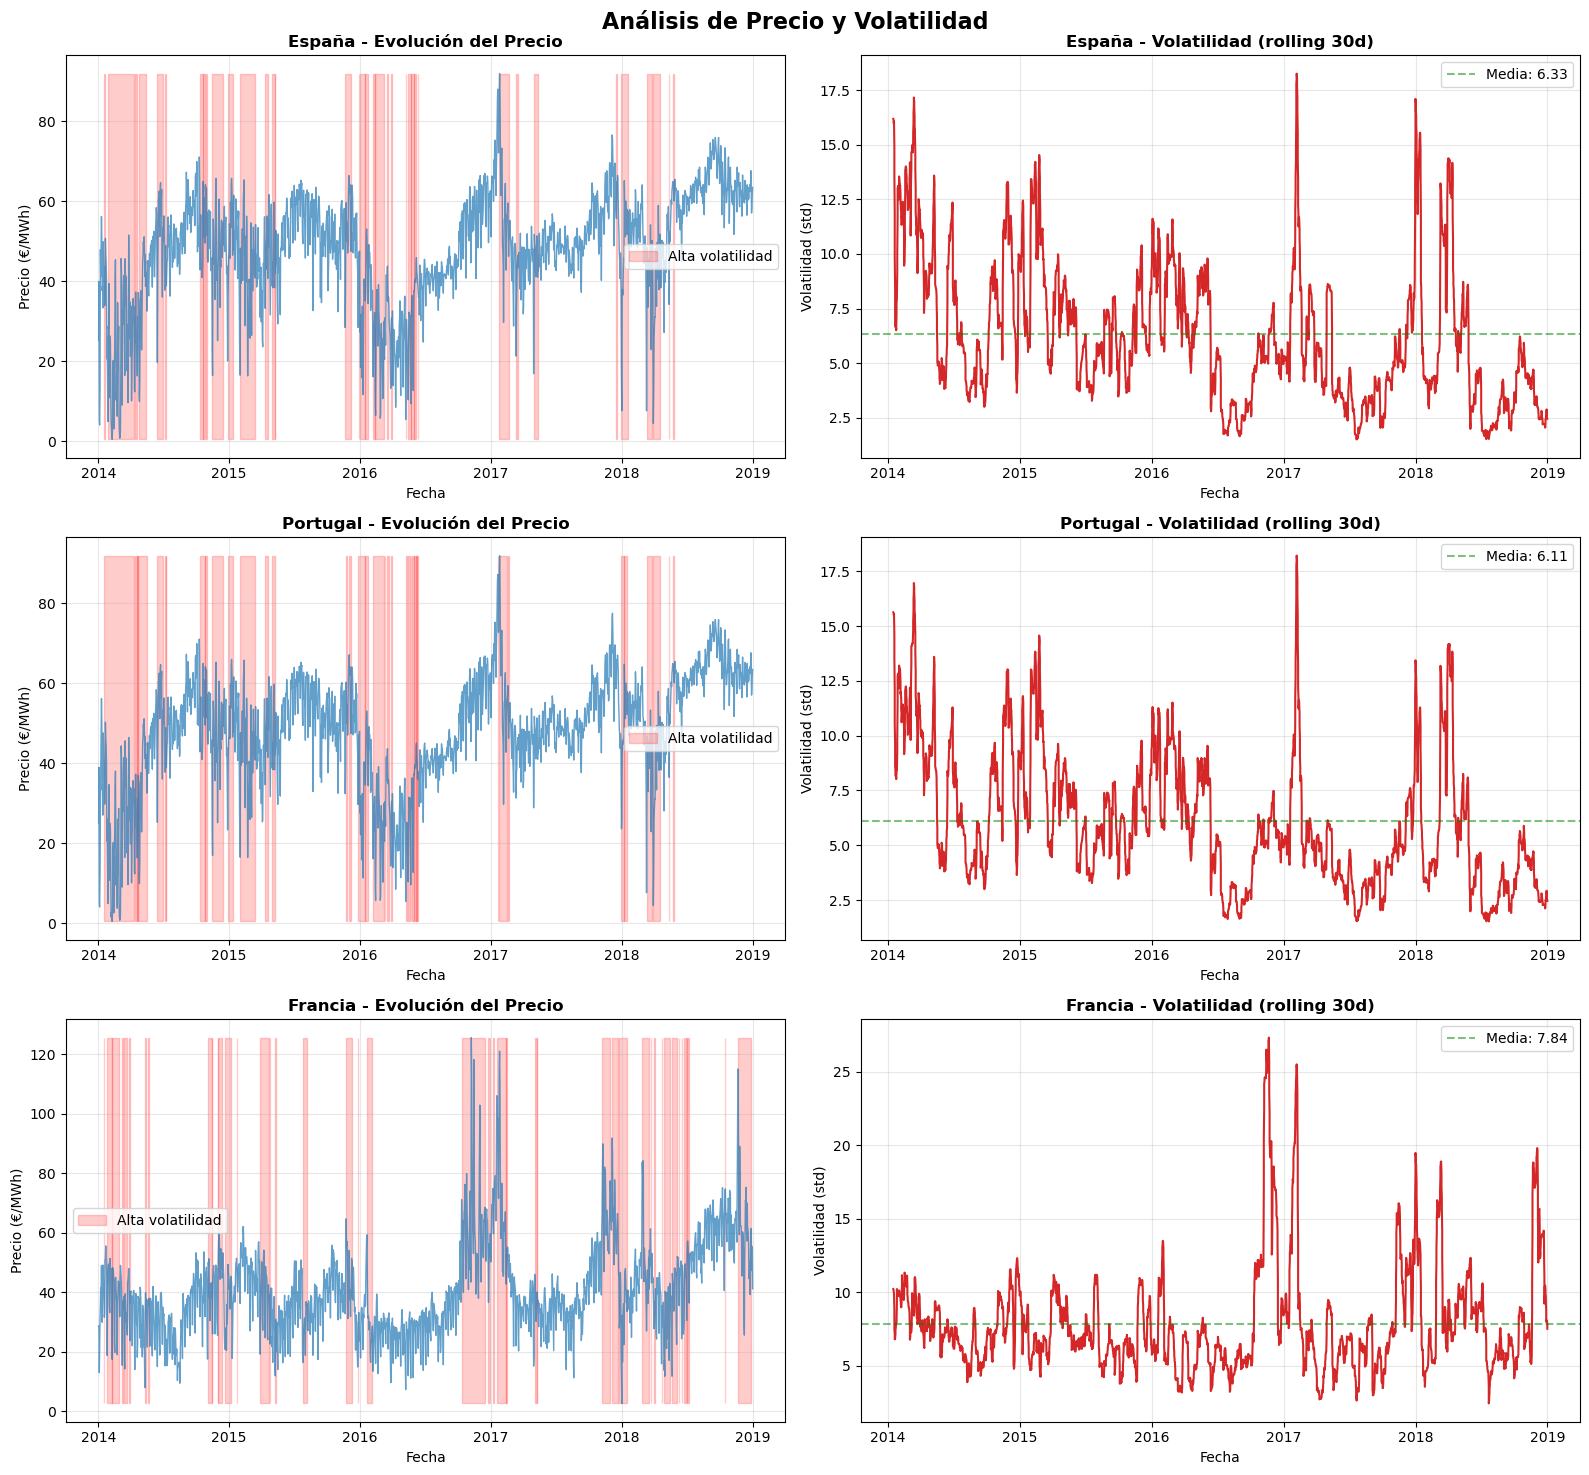

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16756\713008295.py:143: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 0].boxplot(data_boxplot, labels=paises, patch_artist=True)


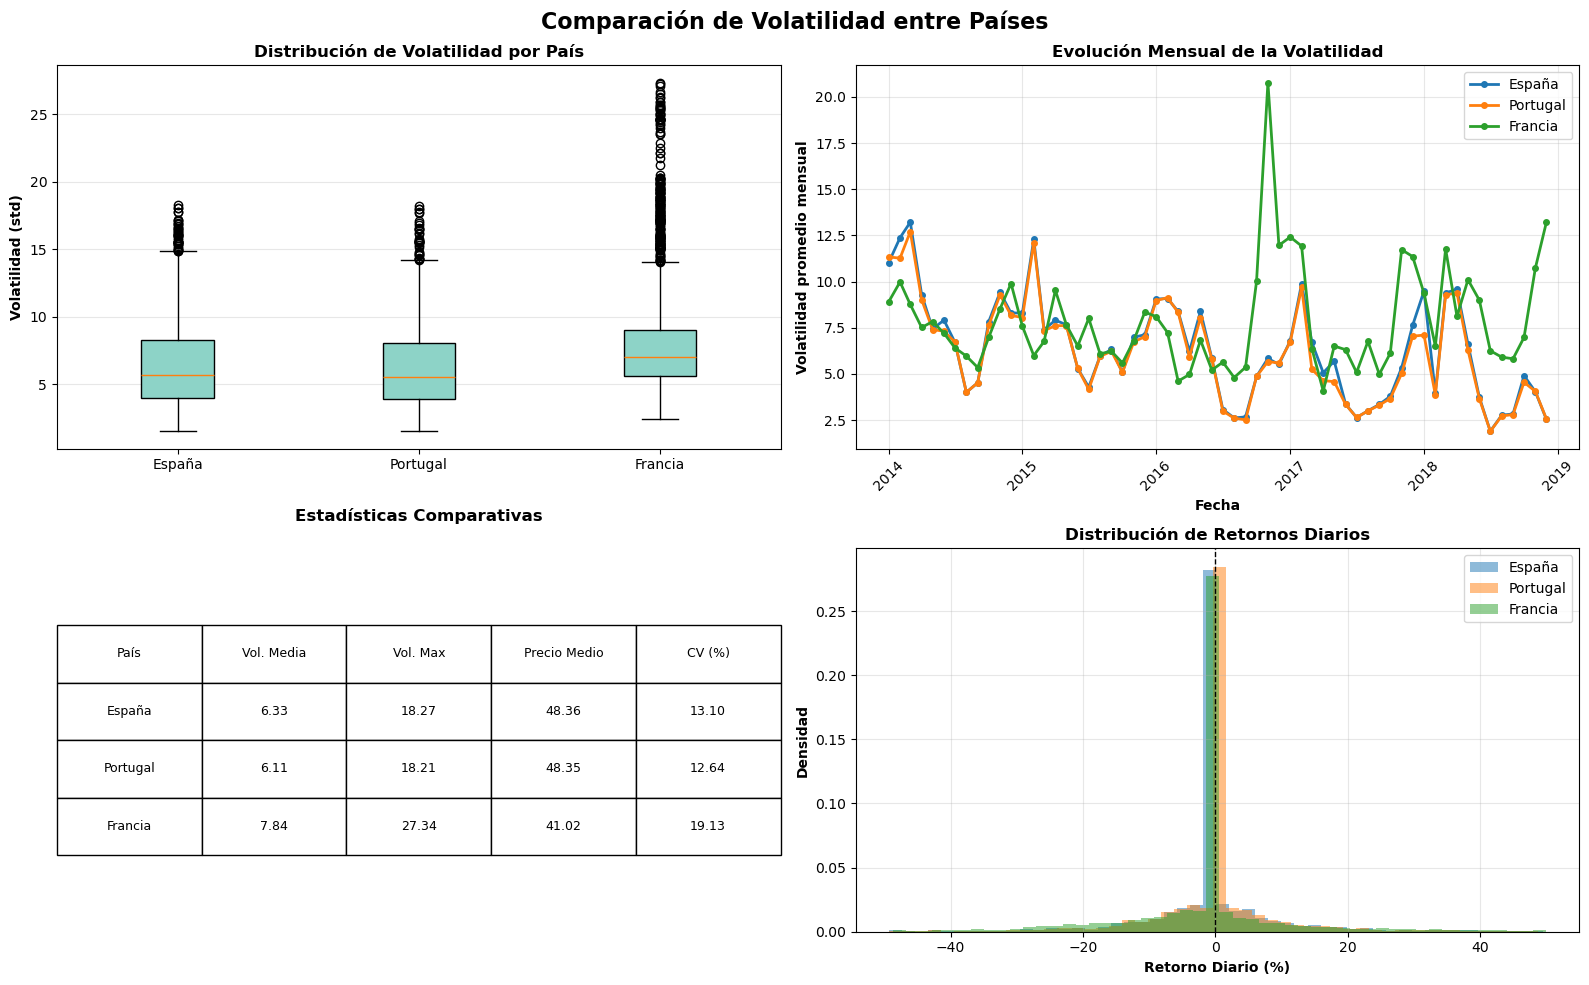

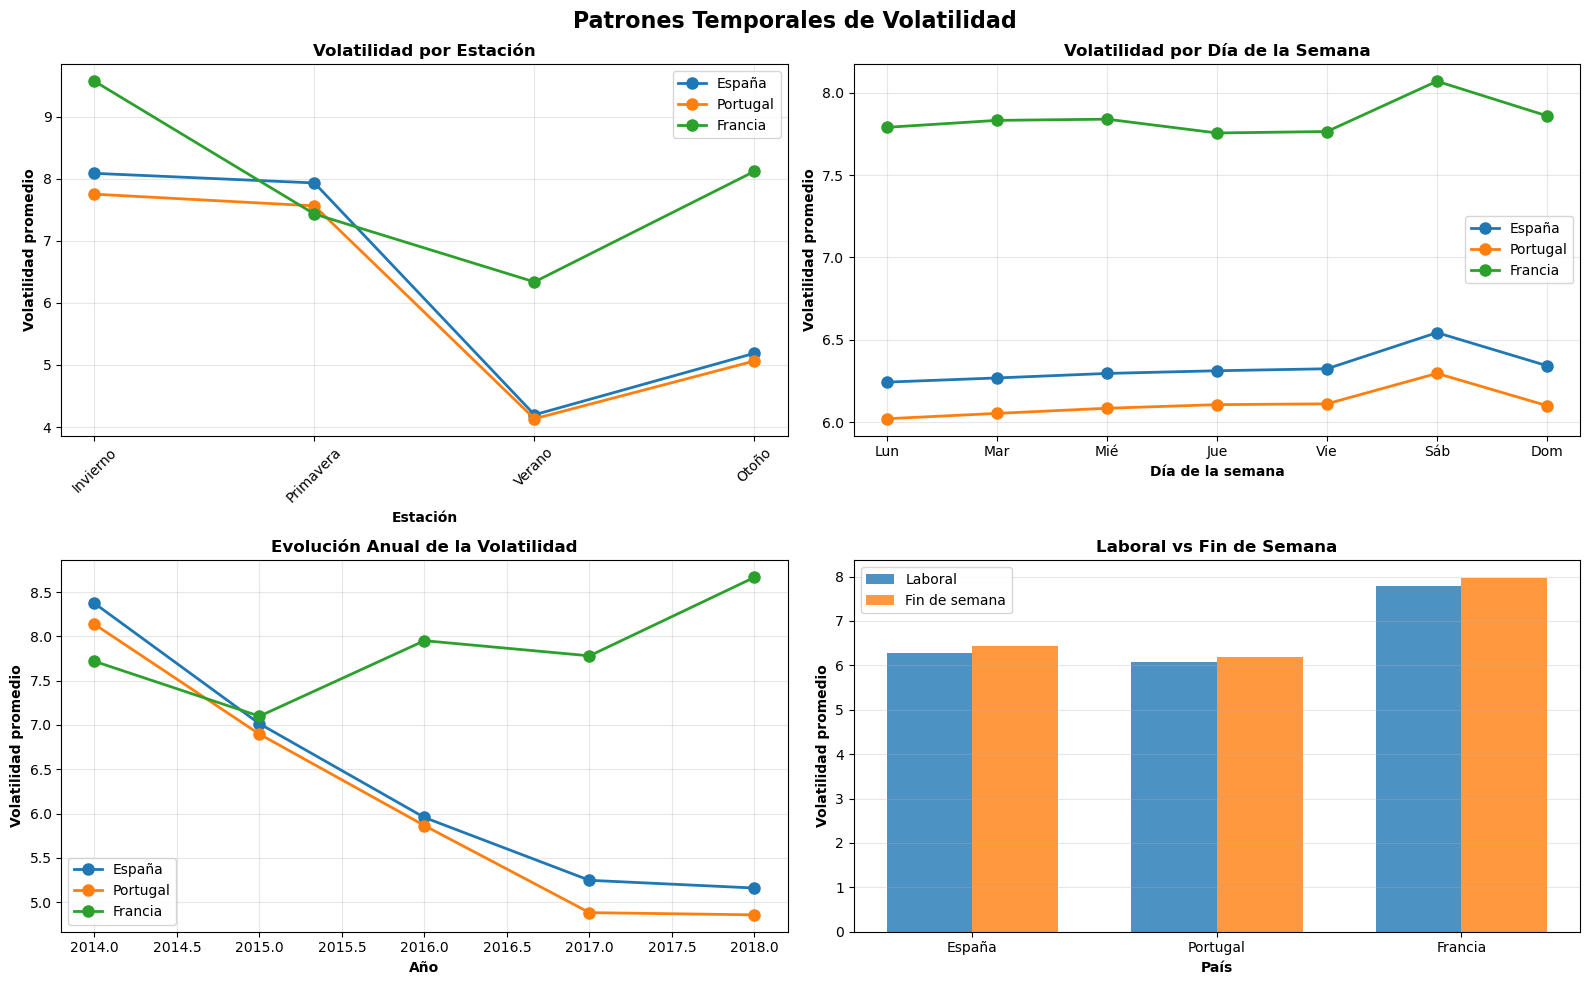

EVENTOS DE ALTA VOLATILIDAD (Percentil 95)

Total de eventos detectados: 42

Top 10 eventos por volatilidad máxima:
    pais        datetime_min  duracion_dias  volatilidad_rolling_max  value_mean
 Francia 2016-11-06 23:00:00             23                27.335371   65.762574
 Francia 2017-01-24 23:00:00             16                25.517056   66.782995
 Francia 2018-11-20 23:00:00             16                19.813893   68.545431
 Francia 2017-12-30 23:00:00              6                19.485591   20.013295
 Francia 2018-03-07 23:00:00              8                18.909728   39.887917
 Francia 2016-11-30 23:00:00             12                18.570193   61.815799
  España 2017-02-02 23:00:00              8                18.266824   50.088667
Portugal 2017-02-02 23:00:00              8                18.211369   50.522552
  España 2014-03-05 23:00:00             14                17.173139   32.225016
  España 2017-12-30 23:00:00              7                17.105897   32.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================
# 1. PREPARACIÓN DE DATOS DE PRECIOS
# ============================================
def preparar_datos_precios(df):
    """
    Filtra y prepara datos de precios para análisis de volatilidad
    """
    # Filtrar solo precios
    df_precios = df[df['name'].str.contains('Precio|precio|Price',
                                             case=False,
                                             na=False)].copy()

    # Asegurar que datetime es tipo datetime
    if not pd.api.types.is_datetime64_any_dtype(df_precios['datetime']):
        df_precios['datetime'] = pd.to_datetime(df_precios['datetime'])

    # Ordenar por fecha
    df_precios = df_precios.sort_values('datetime')

    # Crear features temporales
    df_precios['year'] = df_precios['datetime'].dt.year
    df_precios['mes'] = df_precios['datetime'].dt.month
    df_precios['dia_semana'] = df_precios['datetime'].dt.dayofweek
    df_precios['fecha'] = df_precios['datetime'].dt.date

    print(f"Total de registros de precios: {len(df_precios):,}")
    print(f"Países: {df_precios['geoname'].unique()}")
    print(f"Tipos de precios: {df_precios['name'].unique()}")
    print(f"Rango temporal: {df_precios['datetime'].min()} a {df_precios['datetime'].max()}")

    return df_precios


# ============================================
# 2. CÁLCULO DE MÉTRICAS DE VOLATILIDAD
# ============================================
def calcular_volatilidad(df_precios, ventana=30):
    """
    Calcula diferentes métricas de volatilidad
    """
    resultados = []

    for pais in df_precios['geoname'].unique():
        df_pais = df_precios[df_precios['geoname'] == pais].copy()
        df_pais = df_pais.sort_values('datetime')

        # Volatilidad = Desviación estándar móvil
        df_pais['volatilidad_rolling'] = df_pais['value'].rolling(window=ventana).std()

        # Retornos diarios (cambio porcentual)
        df_pais['retorno_diario'] = df_pais['value'].pct_change() * 100

        # Volatilidad de retornos
        df_pais['volatilidad_retornos'] = df_pais['retorno_diario'].rolling(window=ventana).std()

        # Rango diario (si hay múltiples observaciones por día)
        df_pais['rango_diario'] = df_pais.groupby('fecha')['value'].transform(
            lambda x: x.max() - x.min() if len(x) > 1 else 0
        )

        resultados.append(df_pais)

    df_con_volatilidad = pd.concat(resultados, ignore_index=True)

    return df_con_volatilidad


# ============================================
# 3. VISUALIZACIÓN: PRECIO Y VOLATILIDAD
# ============================================
def grafico_precio_volatilidad(df_precios, ventana=30):
    """
    Gráfico dual: precio y su volatilidad
    """
    df_vol = calcular_volatilidad(df_precios, ventana=ventana)

    paises = df_vol['geoname'].unique()
    n_paises = len(paises)

    fig, axes = plt.subplots(n_paises, 2, figsize=(16, 5*n_paises))
    if n_paises == 1:
        axes = axes.reshape(1, -1)

    for idx, pais in enumerate(paises):
        df_pais = df_vol[df_vol['geoname'] == pais]

        # Gráfico 1: Evolución del precio
        axes[idx, 0].plot(df_pais['datetime'], df_pais['value'],
                         linewidth=1, alpha=0.7, color='#1f77b4')
        axes[idx, 0].set_title(f'{pais} - Evolución del Precio', fontweight='bold')
        axes[idx, 0].set_xlabel('Fecha')
        axes[idx, 0].set_ylabel('Precio (€/MWh)')
        axes[idx, 0].grid(True, alpha=0.3)

        # Sombrear períodos de alta volatilidad
        q75 = df_pais['volatilidad_rolling'].quantile(0.75)
        alta_vol = df_pais['volatilidad_rolling'] > q75
        axes[idx, 0].fill_between(df_pais['datetime'],
                                  df_pais['value'].min(),
                                  df_pais['value'].max(),
                                  where=alta_vol, alpha=0.2, color='red',
                                  label='Alta volatilidad')
        axes[idx, 0].legend()

        # Gráfico 2: Volatilidad
        axes[idx, 1].plot(df_pais['datetime'], df_pais['volatilidad_rolling'],
                         linewidth=1.5, color='#d62728')
        axes[idx, 1].set_title(f'{pais} - Volatilidad (rolling {ventana}d)', fontweight='bold')
        axes[idx, 1].set_xlabel('Fecha')
        axes[idx, 1].set_ylabel('Volatilidad (std)')
        axes[idx, 1].grid(True, alpha=0.3)
        axes[idx, 1].axhline(df_pais['volatilidad_rolling'].mean(),
                            color='green', linestyle='--', alpha=0.5,
                            label=f'Media: {df_pais["volatilidad_rolling"].mean():.2f}')
        axes[idx, 1].legend()

    plt.suptitle('Análisis de Precio y Volatilidad', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================
# 4. COMPARACIÓN DE VOLATILIDAD ENTRE PAÍSES
# ============================================
def comparar_volatilidad_paises(df_precios, ventana=30):
    """
    Compara la volatilidad entre países
    """
    df_vol = calcular_volatilidad(df_precios, ventana=ventana)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Distribución de volatilidad por país
    paises = df_vol['geoname'].unique()
    data_boxplot = [df_vol[df_vol['geoname'] == pais]['volatilidad_rolling'].dropna()
                    for pais in paises]

    bp = axes[0, 0].boxplot(data_boxplot, labels=paises, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#8dd3c7')
    axes[0, 0].set_ylabel('Volatilidad (std)', fontweight='bold')
    axes[0, 0].set_title('Distribución de Volatilidad por País', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)

    # 2. Volatilidad promedio mensual
    df_vol['año_mes'] = df_vol['datetime'].dt.to_period('M')
    monthly_vol = df_vol.groupby(['geoname', 'año_mes'])['volatilidad_rolling'].mean().reset_index()
    monthly_vol['año_mes'] = monthly_vol['año_mes'].dt.to_timestamp()

    for pais in paises:
        df_pais = monthly_vol[monthly_vol['geoname'] == pais]
        axes[0, 1].plot(df_pais['año_mes'], df_pais['volatilidad_rolling'],
                       marker='o', label=pais, linewidth=2, markersize=4)

    axes[0, 1].set_xlabel('Fecha', fontweight='bold')
    axes[0, 1].set_ylabel('Volatilidad promedio mensual', fontweight='bold')
    axes[0, 1].set_title('Evolución Mensual de la Volatilidad', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. Tabla de estadísticas
    axes[1, 0].axis('off')

    stats_data = []
    for pais in paises:
        df_pais = df_vol[df_vol['geoname'] == pais]
        stats_data.append({
            'País': pais,
            'Vol. Media': f"{df_pais['volatilidad_rolling'].mean():.2f}",
            'Vol. Max': f"{df_pais['volatilidad_rolling'].max():.2f}",
            'Precio Medio': f"{df_pais['value'].mean():.2f}",
            'CV (%)': f"{(df_pais['volatilidad_rolling'].mean() / df_pais['value'].mean() * 100):.2f}"
        })

    stats_df = pd.DataFrame(stats_data)
    table = axes[1, 0].table(cellText=stats_df.values,
                            colLabels=stats_df.columns,
                            cellLoc='center',
                            loc='center',
                            bbox=[0, 0.2, 1, 0.6])
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    axes[1, 0].set_title('Estadísticas Comparativas', fontweight='bold', pad=20)

    # 4. Distribución de retornos diarios
    for pais in paises:
        df_pais = df_vol[df_vol['geoname'] == pais]
        retornos = df_pais['retorno_diario'].dropna()
        retornos = retornos[(retornos > -50) & (retornos < 50)]  # Filtrar outliers extremos
        axes[1, 1].hist(retornos, bins=50, alpha=0.5, label=pais, density=True)

    axes[1, 1].set_xlabel('Retorno Diario (%)', fontweight='bold')
    axes[1, 1].set_ylabel('Densidad', fontweight='bold')
    axes[1, 1].set_title('Distribución de Retornos Diarios', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)

    plt.suptitle('Comparación de Volatilidad entre Países', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================
# 5. ANÁLISIS TEMPORAL DE VOLATILIDAD
# ============================================
def volatilidad_temporal(df_precios, ventana=30):
    """
    Analiza cómo varía la volatilidad en el tiempo (estaciones, días)
    """
    df_vol = calcular_volatilidad(df_precios, ventana=ventana)

    # Agregar features temporales
    df_vol['hora'] = pd.to_datetime(df_vol['time'], format='%H:%M:%S', errors='coerce').dt.hour
    df_vol['es_fin_semana'] = df_vol['dia_semana'].isin([5, 6])

    def get_estacion(mes):
        if mes in [12, 1, 2]:
            return 'Invierno'
        elif mes in [3, 4, 5]:
            return 'Primavera'
        elif mes in [6, 7, 8]:
            return 'Verano'
        else:
            return 'Otoño'

    df_vol['estacion'] = df_vol['mes'].apply(get_estacion)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Volatilidad por estación
    estacion_order = ['Invierno', 'Primavera', 'Verano', 'Otoño']
    paises = df_vol['geoname'].unique()

    for pais in paises:
        df_pais = df_vol[df_vol['geoname'] == pais]
        vol_estacion = df_pais.groupby('estacion')['volatilidad_rolling'].mean()
        vol_estacion = vol_estacion.reindex(estacion_order)
        axes[0, 0].plot(estacion_order, vol_estacion.values,
                       marker='o', label=pais, linewidth=2, markersize=8)

    axes[0, 0].set_xlabel('Estación', fontweight='bold')
    axes[0, 0].set_ylabel('Volatilidad promedio', fontweight='bold')
    axes[0, 0].set_title('Volatilidad por Estación', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2. Volatilidad por día de la semana
    dias_nombres = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

    for pais in paises:
        df_pais = df_vol[df_vol['geoname'] == pais]
        vol_dia = df_pais.groupby('dia_semana')['volatilidad_rolling'].mean()
        axes[0, 1].plot(range(7), vol_dia.values,
                       marker='o', label=pais, linewidth=2, markersize=8)

    axes[0, 1].set_xlabel('Día de la semana', fontweight='bold')
    axes[0, 1].set_ylabel('Volatilidad promedio', fontweight='bold')
    axes[0, 1].set_title('Volatilidad por Día de la Semana', fontweight='bold')
    axes[0, 1].set_xticks(range(7))
    axes[0, 1].set_xticklabels(dias_nombres)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Volatilidad por año
    for pais in paises:
        df_pais = df_vol[df_vol['geoname'] == pais]
        vol_anual = df_pais.groupby('year')['volatilidad_rolling'].mean()
        axes[1, 0].plot(vol_anual.index, vol_anual.values,
                       marker='o', label=pais, linewidth=2, markersize=8)

    axes[1, 0].set_xlabel('Año', fontweight='bold')
    axes[1, 0].set_ylabel('Volatilidad promedio', fontweight='bold')
    axes[1, 0].set_title('Evolución Anual de la Volatilidad', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Fin de semana vs laboral
    vol_comparacion = []
    for pais in paises:
        df_pais = df_vol[df_vol['geoname'] == pais]
        vol_laboral = df_pais[~df_pais['es_fin_semana']]['volatilidad_rolling'].mean()
        vol_finde = df_pais[df_pais['es_fin_semana']]['volatilidad_rolling'].mean()
        vol_comparacion.append({
            'País': pais,
            'Laboral': vol_laboral,
            'Fin de semana': vol_finde
        })

    df_comp = pd.DataFrame(vol_comparacion)
    x = np.arange(len(df_comp))
    width = 0.35

    axes[1, 1].bar(x - width/2, df_comp['Laboral'], width,
                  label='Laboral', alpha=0.8)
    axes[1, 1].bar(x + width/2, df_comp['Fin de semana'], width,
                  label='Fin de semana', alpha=0.8)
    axes[1, 1].set_xlabel('País', fontweight='bold')
    axes[1, 1].set_ylabel('Volatilidad promedio', fontweight='bold')
    axes[1, 1].set_title('Laboral vs Fin de Semana', fontweight='bold')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(df_comp['País'])
    axes[1, 1].legend()
    axes[1, 1].grid(axis='y', alpha=0.3)

    plt.suptitle('Patrones Temporales de Volatilidad', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================
# 6. EVENTOS DE ALTA VOLATILIDAD
# ============================================
def identificar_eventos_alta_volatilidad(df_precios, umbral_percentil=95, ventana=30):
    """
    Identifica y analiza períodos de volatilidad extrema
    """
    df_vol = calcular_volatilidad(df_precios, ventana=ventana)

    resultados = []

    for pais in df_vol['geoname'].unique():
        df_pais = df_vol[df_vol['geoname'] == pais].copy()

        # Definir umbral de alta volatilidad
        umbral = df_pais['volatilidad_rolling'].quantile(umbral_percentil / 100)

        # Identificar eventos
        df_pais['alta_volatilidad'] = df_pais['volatilidad_rolling'] > umbral

        # Agrupar eventos consecutivos
        df_pais['grupo_evento'] = (df_pais['alta_volatilidad'] !=
                                   df_pais['alta_volatilidad'].shift()).cumsum()

        # Filtrar solo eventos de alta volatilidad
        eventos = df_pais[df_pais['alta_volatilidad']].groupby('grupo_evento').agg({
            'datetime': ['min', 'max', 'count'],
            'volatilidad_rolling': 'max',
            'value': ['mean', 'min', 'max']
        }).reset_index(drop=True)

        eventos.columns = ['_'.join(col).strip('_') for col in eventos.columns]
        eventos['pais'] = pais
        eventos['duracion_dias'] = (pd.to_datetime(eventos['datetime_max']) -
                                    pd.to_datetime(eventos['datetime_min'])).dt.days + 1

        resultados.append(eventos)

    df_eventos = pd.concat(resultados, ignore_index=True)

    print("=" * 80)
    print(f"EVENTOS DE ALTA VOLATILIDAD (Percentil {umbral_percentil})")
    print("=" * 80)
    print(f"\nTotal de eventos detectados: {len(df_eventos)}")
    print(f"\nTop 10 eventos por volatilidad máxima:")
    print(df_eventos.nlargest(10, 'volatilidad_rolling_max')[
        ['pais', 'datetime_min', 'duracion_dias', 'volatilidad_rolling_max', 'value_mean']
    ].to_string(index=False))

    return df_eventos


# ============================================
# EJEMPLO DE USO COMPLETO
# ============================================

# 1. Preparar datos de precios
df_precios = preparar_datos_precios(df)

# 2. Gráfico de precio y volatilidad
grafico_precio_volatilidad(df_precios, ventana=30)

# 3. Comparar volatilidad entre países
comparar_volatilidad_paises(df_precios, ventana=30)

# 4. Análisis temporal de volatilidad
volatilidad_temporal(df_precios, ventana=30)

# 5. Identificar eventos extremos
eventos = identificar_eventos_alta_volatilidad(df_precios, umbral_percentil=95, ventana=30)


EVENTOS DE ALTA VOLATILIDAD (Percentil 95)

Total de eventos detectados: 42

Top 10 eventos por volatilidad máxima:
    pais        datetime_min  duracion_dias  volatilidad_rolling_max  value_mean
 Francia 2016-11-06 23:00:00             23                27.335371   65.762574
 Francia 2017-01-24 23:00:00             16                25.517056   66.782995
 Francia 2018-11-20 23:00:00             16                19.813893   68.545431
 Francia 2017-12-30 23:00:00              6                19.485591   20.013295
 Francia 2018-03-07 23:00:00              8                18.909728   39.887917
 Francia 2016-11-30 23:00:00             12                18.570193   61.815799
  España 2017-02-02 23:00:00              8                18.266824   50.088667
Portugal 2017-02-02 23:00:00              8                18.211369   50.522552
  España 2014-03-05 23:00:00             14                17.173139   32.225016
  España 2017-12-30 23:00:00              7                17.105897   32.

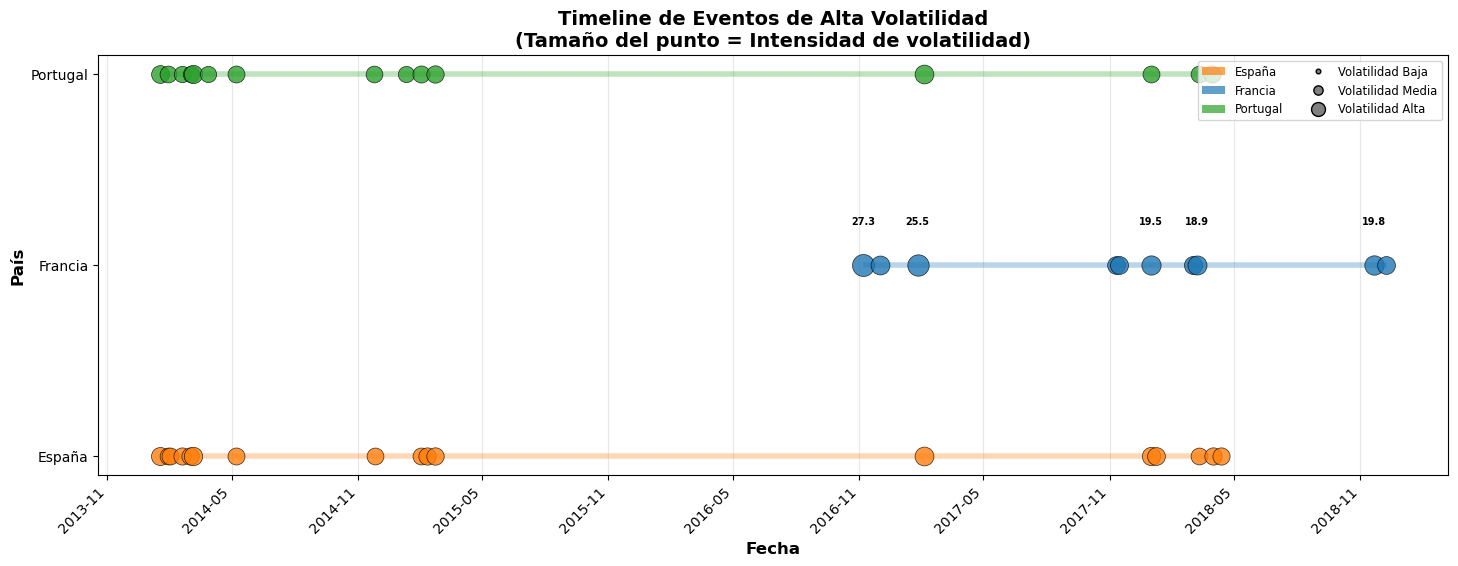

📊 Analizando características por país...


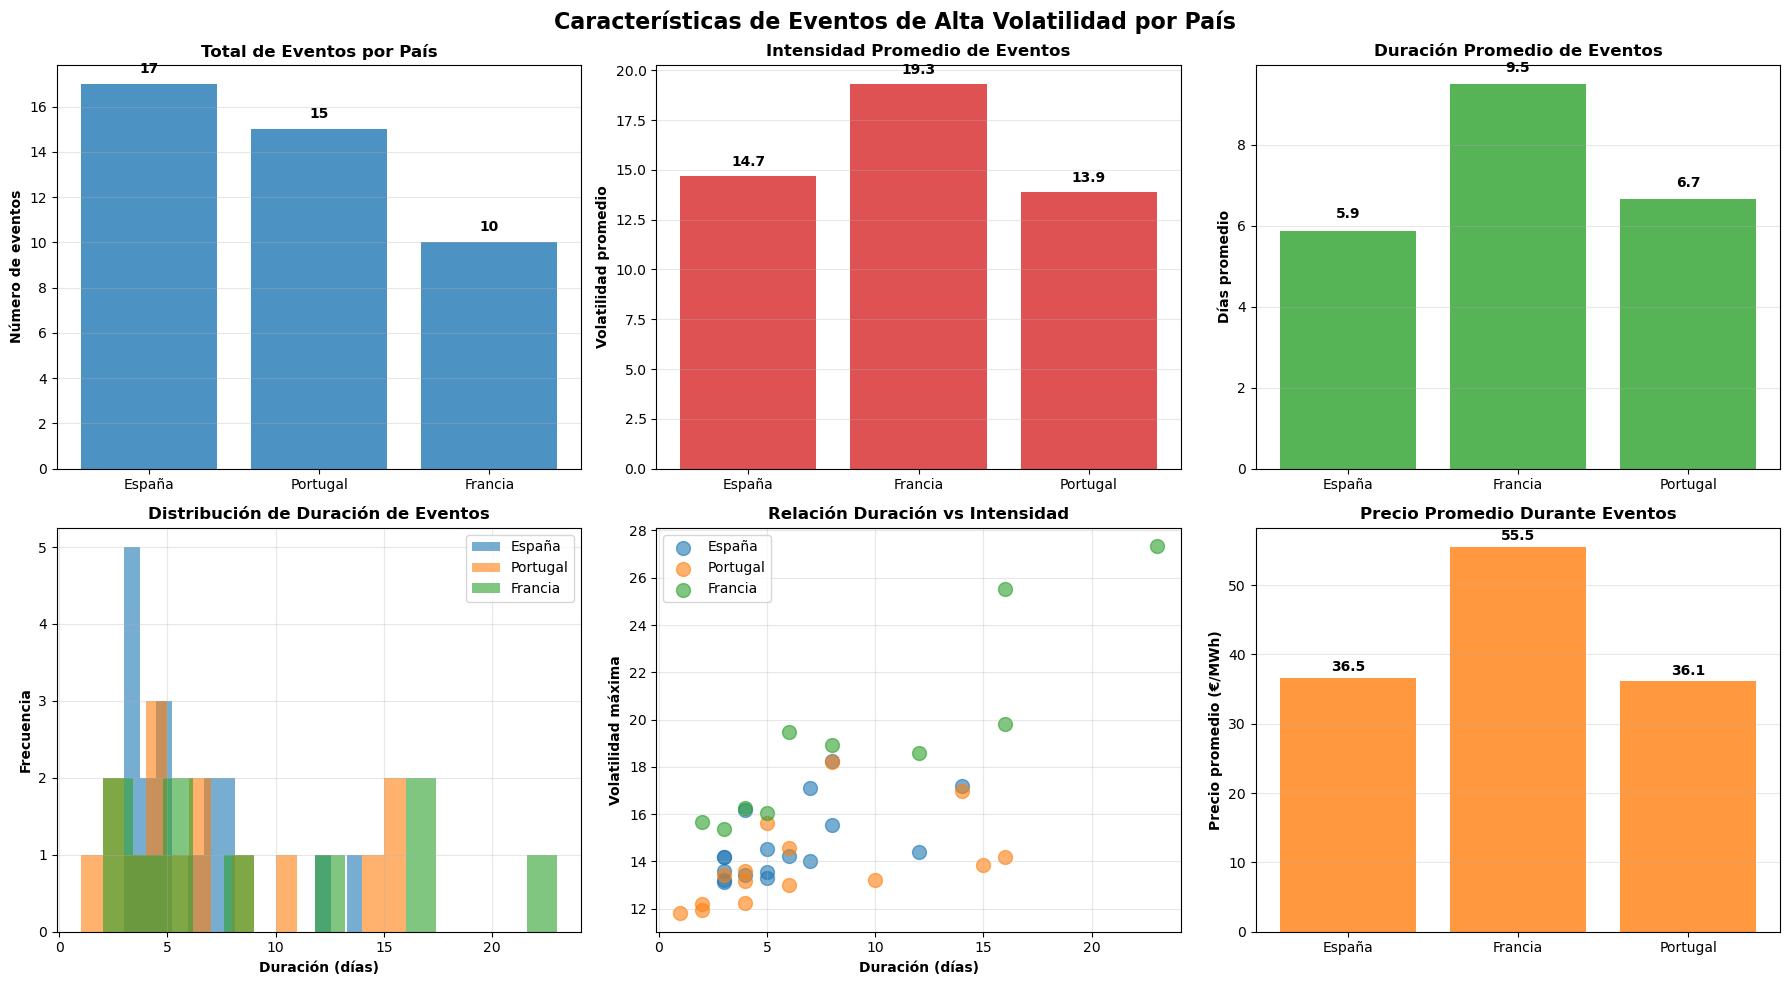

📊 Analizando estacionalidad...


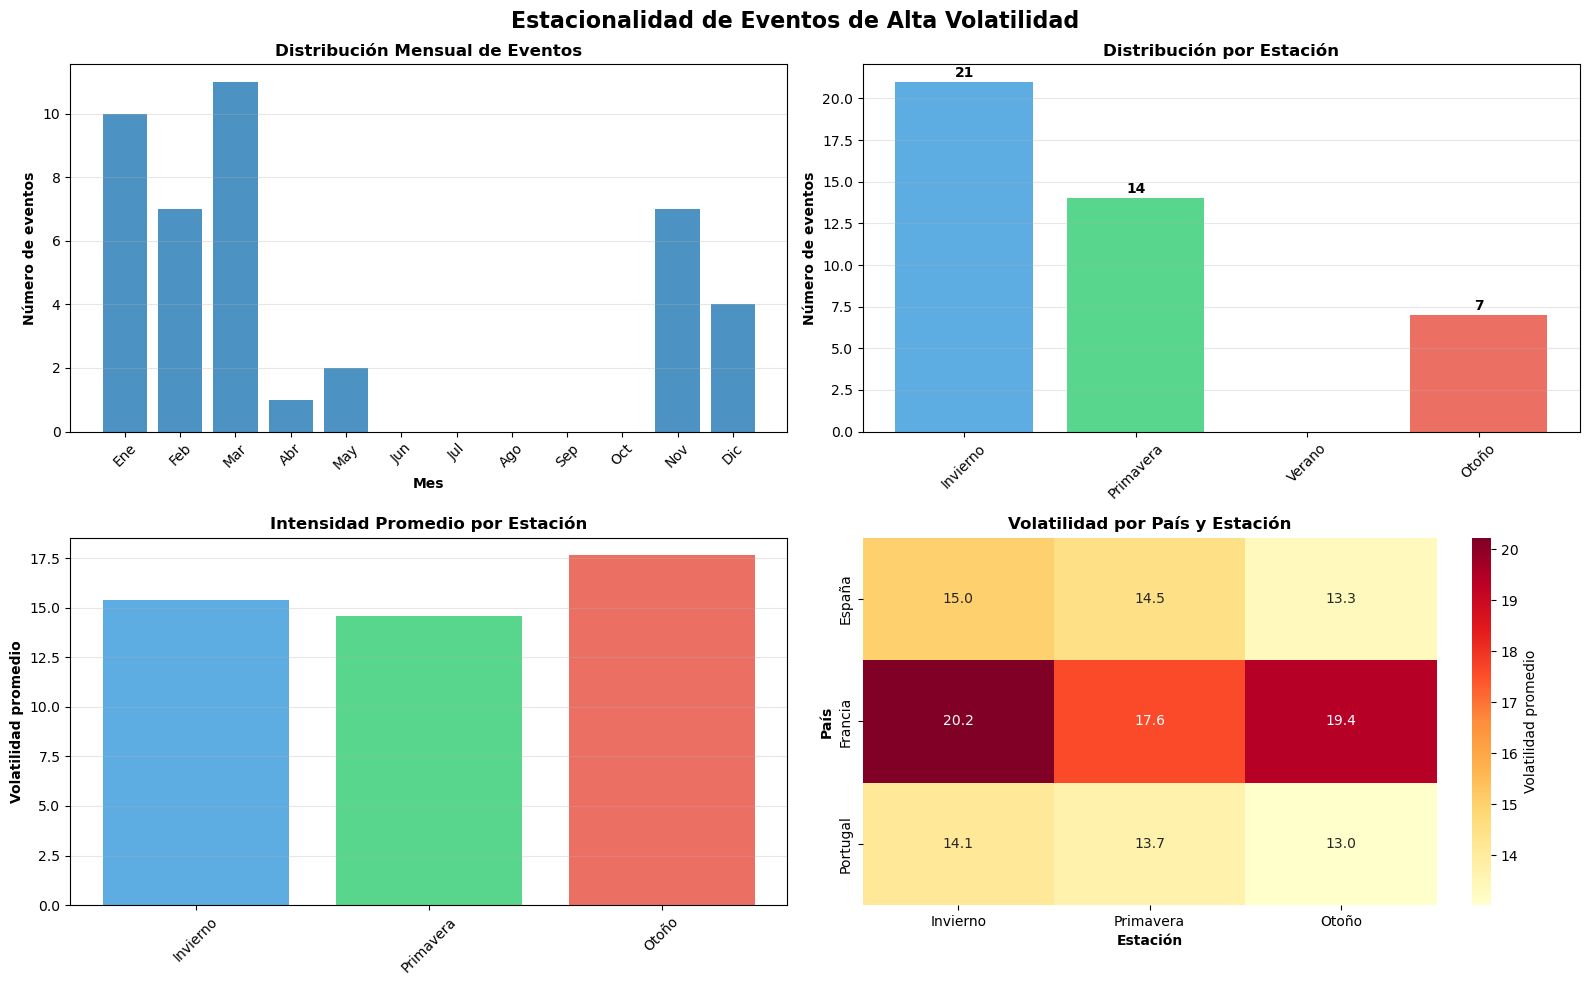

RESUMEN ESTACIONAL

Estación con más eventos: Invierno (21 eventos)
Estación con mayor volatilidad: Otoño (17.64)

Mes más crítico: Mar (11 eventos)
📊 Análisis detallado de top 5 eventos...


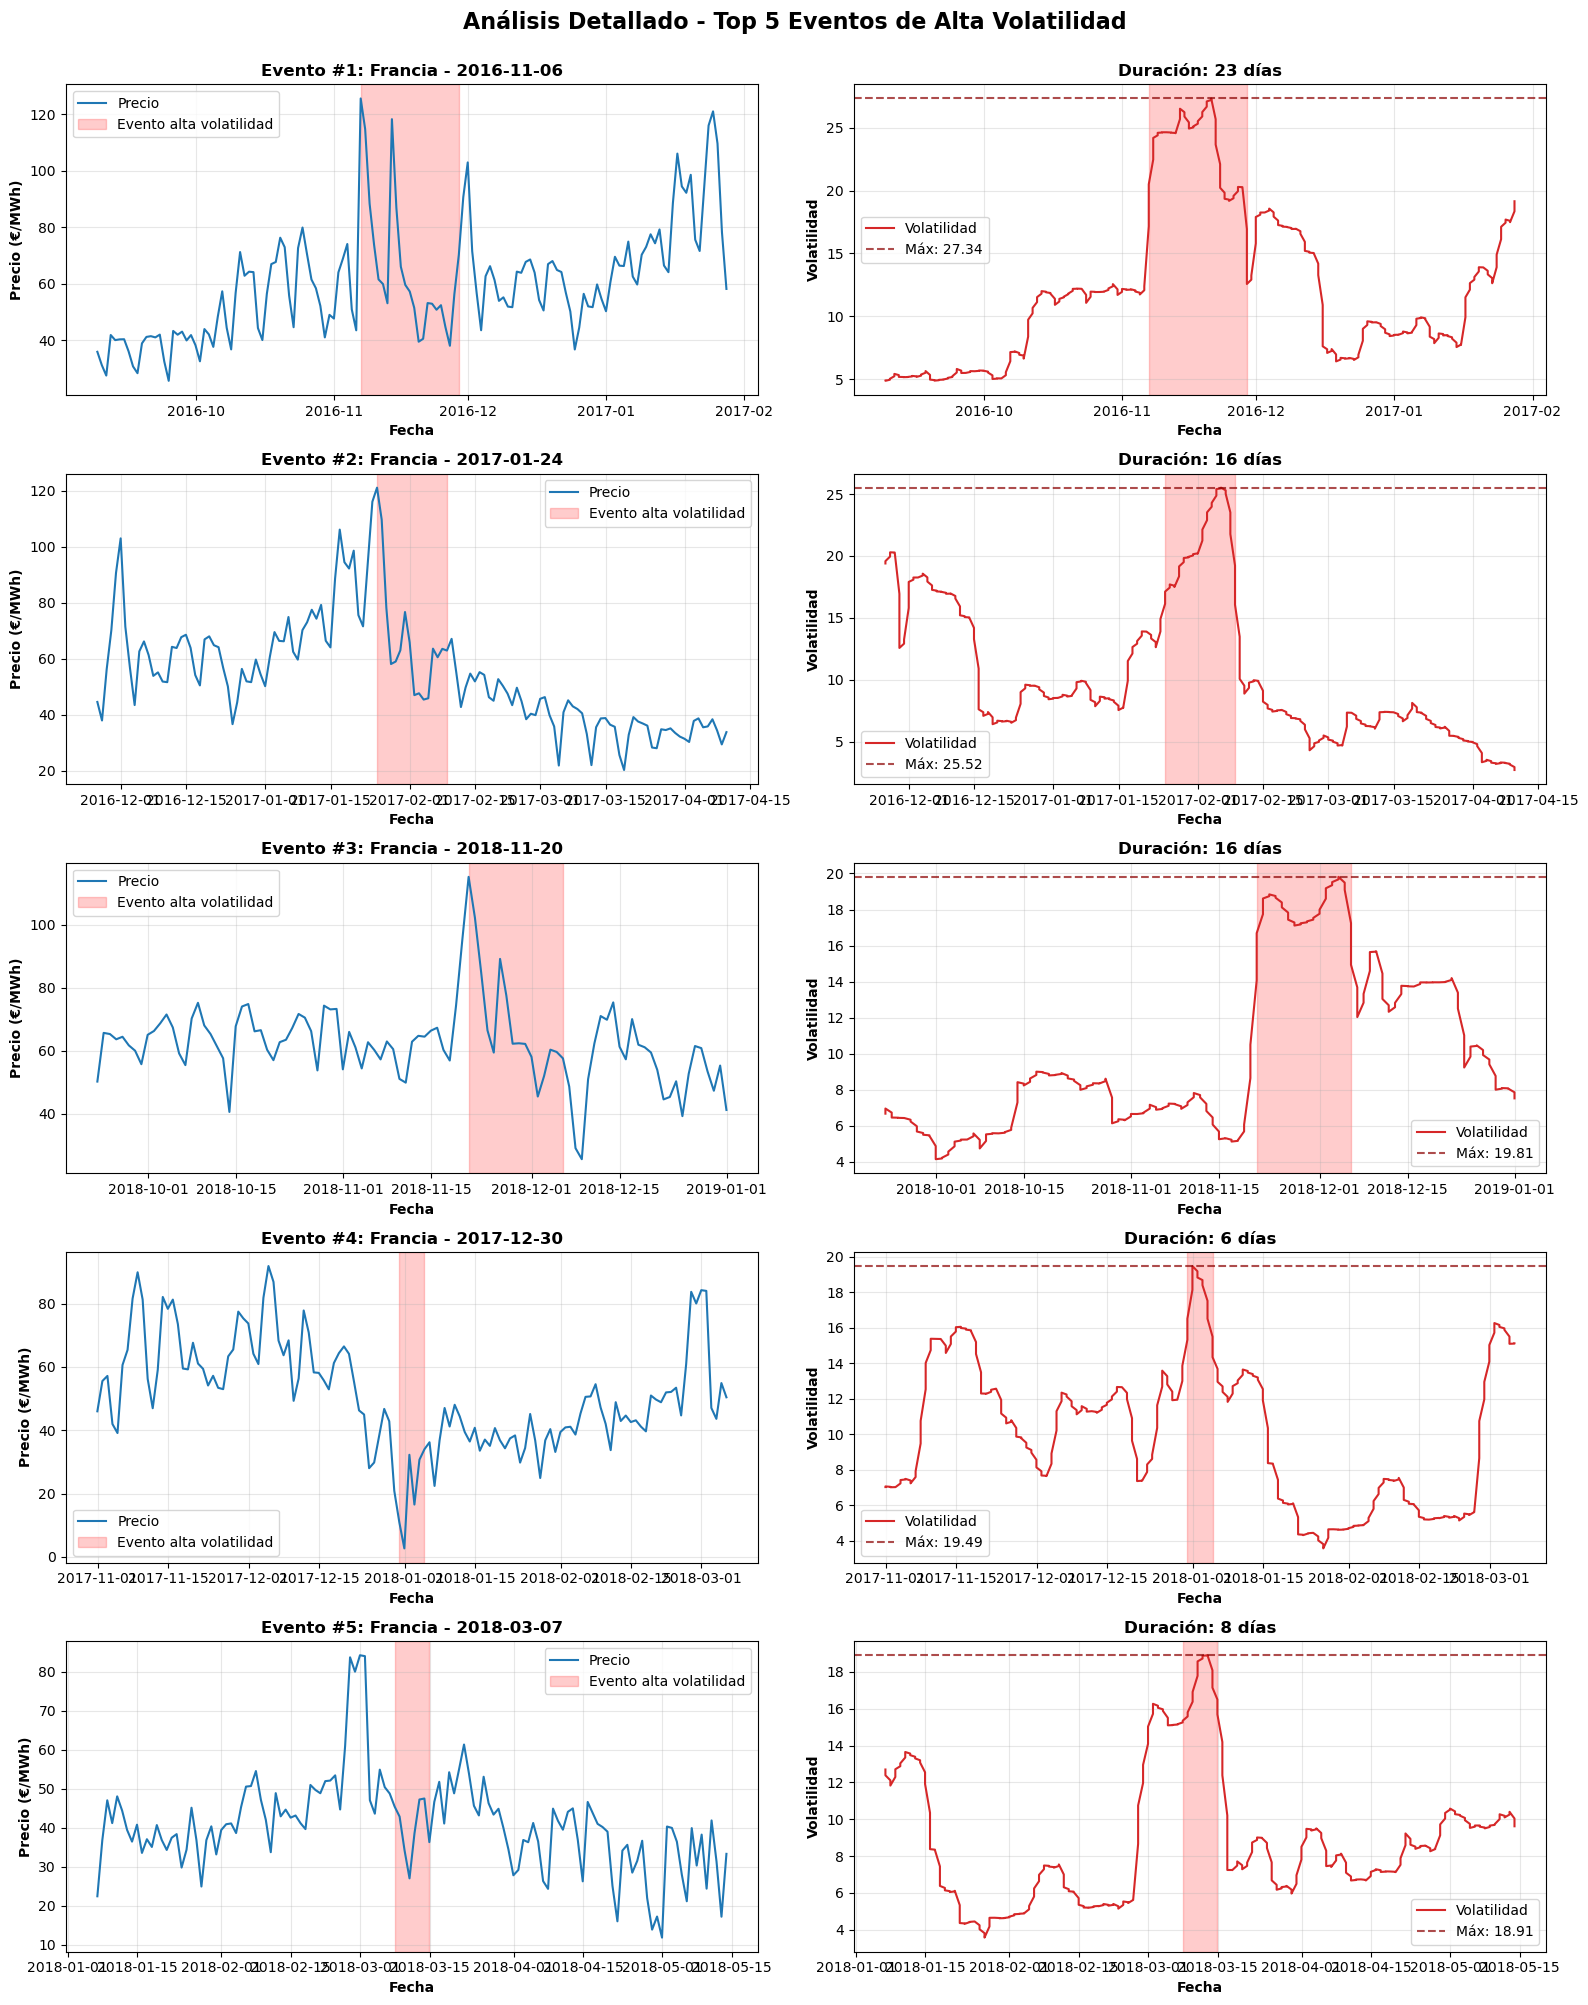


✅ Análisis completo finalizado!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle

# ============================================
# 1. TIMELINE DE EVENTOS EXTREMOS
# ============================================
def timeline_eventos_volatilidad(df_eventos):
    """
    Visualiza todos los eventos de alta volatilidad en una línea temporal
    """
    df_eventos = df_eventos.copy()
    df_eventos['datetime_min'] = pd.to_datetime(df_eventos['datetime_min'])
    df_eventos['datetime_max'] = pd.to_datetime(df_eventos['datetime_max'])

    fig, ax = plt.subplots(figsize=(15, 6)) # Reverted to a more reasonable width for clarity

    # Colores por país
    colores_pais = {'España': '#ff7f0e', 'Francia': '#1f77b4', 'Portugal': '#2ca02c'}

    paises = sorted(df_eventos['pais'].unique())
    y_pos = {pais: i for i, pais in enumerate(paises)}

    # Plot a horizontal line for each country's entire time range
    for pais in paises:
        min_date = df_eventos[df_eventos['pais'] == pais]['datetime_min'].min()
        max_date = df_eventos[df_eventos['pais'] == pais]['datetime_max'].max()
        ax.hlines(y=y_pos[pais], xmin=min_date, xmax=max_date,
                  colors=colores_pais.get(pais, 'gray'), linewidth=4, alpha=0.3,
                  label=pais)

    # Plot events as scatter points on the lines
    for _, evento in df_eventos.iterrows():
        pais = evento['pais']
        inicio = evento['datetime_min']
        fin = evento['datetime_max']
        volatilidad = evento['volatilidad_rolling_max']

        # Use a single point for the start of the event, with size indicating volatility
        size = (volatilidad / df_eventos['volatilidad_rolling_max'].max()) * 200 + 50 # Scale size
        ax.scatter(inicio, y_pos[pais], s=size, color=colores_pais.get(pais, 'gray'),
                   edgecolor='black', linewidth=0.5, zorder=2, alpha=0.8)

        # Optional: Add text for very high volatility events
        if volatilidad > df_eventos['volatilidad_rolling_max'].quantile(0.90):
            ax.text(inicio, y_pos[pais] + 0.2, f'{volatilidad:.1f}',
                   ha='center', va='bottom', fontsize=7, fontweight='bold')

    # Configurar ejes
    ax.set_yticks(list(y_pos.values()))
    ax.set_yticklabels(list(y_pos.keys()))

    # Formatear eje x como fechas
    import matplotlib.dates as mdates
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

    ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
    ax.set_ylabel('País', fontsize=12, fontweight='bold')
    ax.set_title('Timeline de Eventos de Alta Volatilidad\n(Tamaño del punto = Intensidad de volatilidad)',
                fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

    # Leyenda for colors/countries (using Patch for custom legend) and for size
    from matplotlib.patches import Patch
    legend_elements = []
    for pais in paises:
        legend_elements.append(Patch(facecolor=colores_pais.get(pais, 'gray'), alpha=0.7, label=pais))

    # Create a dummy scatter for size legend
    for s_val, s_label in zip([100, 200, 300], ['Baja', 'Media', 'Alta']):
        legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', label=f'Volatilidad {s_label}',
                                          markerfacecolor='gray', markersize=s_val/30, markeredgecolor='black'))

    ax.legend(handles=legend_elements, loc='upper right', ncol=2, fontsize='small')

    fig.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.2)
    plt.show()


# ============================================
# 2. ANÁLISIS DETALLADO DE EVENTOS TOP
# ============================================
def analizar_evento_detalle(df_precios, df_eventos, top_n=5, ventana=30):
    """
    Analiza en detalle los eventos más extremos
    """
    # Calcular volatilidad
    df_vol = calcular_volatilidad(df_precios, ventana=ventana)

    # Top eventos
    top_eventos = df_eventos.nlargest(top_n, 'volatilidad_rolling_max')

    n_eventos = len(top_eventos)
    fig, axes = plt.subplots(n_eventos, 2, figsize=(16, 4*n_eventos))
    if n_eventos == 1:
        axes = axes.reshape(1, -1)

    for idx, (_, evento) in enumerate(top_eventos.iterrows()):
        pais = evento['pais']
        fecha_inicio = pd.to_datetime(evento['datetime_min'])
        fecha_fin = pd.to_datetime(evento['datetime_max'])

        # Ampliar ventana para contexto (60 días antes y después)
        ventana_contexto = pd.Timedelta(days=60)
        fecha_plot_inicio = fecha_inicio - ventana_contexto
        fecha_plot_fin = fecha_fin + ventana_contexto

        # Filtrar datos
        df_evento = df_vol[
            (df_vol['geoname'] == pais) &
            (df_vol['datetime'] >= fecha_plot_inicio) &
            (df_vol['datetime'] <= fecha_plot_fin)
        ].copy()

        if len(df_evento) == 0:
            continue

        # Gráfico 1: Precio
        axes[idx, 0].plot(df_evento['datetime'], df_evento['value'],
                         linewidth=1.5, color='#1f77b4', label='Precio')

        # Sombrear período del evento
        axes[idx, 0].axvspan(fecha_inicio, fecha_fin, alpha=0.2, color='red',
                            label='Evento alta volatilidad')

        axes[idx, 0].set_xlabel('Fecha', fontweight='bold')
        axes[idx, 0].set_ylabel('Precio (€/MWh)', fontweight='bold')
        axes[idx, 0].set_title(f'Evento #{idx+1}: {pais} - {fecha_inicio.strftime("%Y-%m-%d")}',
                              fontweight='bold')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)

        # Gráfico 2: Volatilidad
        axes[idx, 1].plot(df_evento['datetime'], df_evento['volatilidad_rolling'],
                         linewidth=1.5, color='#d62728', label='Volatilidad')
        axes[idx, 1].axvspan(fecha_inicio, fecha_fin, alpha=0.2, color='red')
        axes[idx, 1].axhline(evento['volatilidad_rolling_max'],
                            color='darkred', linestyle='--', alpha=0.7,
                            label=f'Máx: {evento["volatilidad_rolling_max"]:.2f}')

        axes[idx, 1].set_xlabel('Fecha', fontweight='bold')
        axes[idx, 1].set_ylabel('Volatilidad', fontweight='bold')
        axes[idx, 1].set_title(f'Duración: {evento["duracion_dias"]} días', fontweight='bold')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, alpha=0.3)

    plt.suptitle(f'Análisis Detallado - Top {top_n} Eventos de Alta Volatilidad',
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()


# ============================================
# 3. CARACTERÍSTICAS DE EVENTOS POR PAÍS
# ============================================
def caracteristicas_eventos_por_pais(df_eventos):
    """
    Compara características de eventos entre países
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    paises = df_eventos['pais'].unique()

    # 1. Número de eventos por país
    eventos_pais = df_eventos['pais'].value_counts()
    axes[0, 0].bar(eventos_pais.index, eventos_pais.values, alpha=0.8)
    axes[0, 0].set_ylabel('Número de eventos', fontweight='bold')
    axes[0, 0].set_title('Total de Eventos por País', fontweight='bold')
    axes[0, 0].grid(axis='y', alpha=0.3)

    for i, v in enumerate(eventos_pais.values):
        axes[0, 0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    # 2. Volatilidad máxima promedio por país
    vol_max_pais = df_eventos.groupby('pais')['volatilidad_rolling_max'].mean()
    axes[0, 1].bar(vol_max_pais.index, vol_max_pais.values,
                  color='#d62728', alpha=0.8)
    axes[0, 1].set_ylabel('Volatilidad promedio', fontweight='bold')
    axes[0, 1].set_title('Intensidad Promedio de Eventos', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

    for i, v in enumerate(vol_max_pais.values):
        axes[0, 1].text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

    # 3. Duración promedio por país
    duracion_pais = df_eventos.groupby('pais')['duracion_dias'].mean()
    axes[0, 2].bar(duracion_pais.index, duracion_pais.values,
                  color='#2ca02c', alpha=0.8)
    axes[0, 2].set_ylabel('Días promedio', fontweight='bold')
    axes[0, 2].set_title('Duración Promedio de Eventos', fontweight='bold')
    axes[0, 2].grid(axis='y', alpha=0.3)

    for i, v in enumerate(duracion_pais.values):
        axes[0, 2].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

    # 4. Distribución de duración por país
    for pais in paises:
        duraciones = df_eventos[df_eventos['pais'] == pais]['duracion_dias']
        axes[1, 0].hist(duraciones, bins=15, alpha=0.6, label=pais)

    axes[1, 0].set_xlabel('Duración (días)', fontweight='bold')
    axes[1, 0].set_ylabel('Frecuencia', fontweight='bold')
    axes[1, 0].set_title('Distribución de Duración de Eventos', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 5. Volatilidad vs Duración (scatter)
    for pais in paises:
        df_pais = df_eventos[df_eventos['pais'] == pais]
        axes[1, 1].scatter(df_pais['duracion_dias'],
                          df_pais['volatilidad_rolling_max'],
                          s=100, alpha=0.6, label=pais)

    axes[1, 1].set_xlabel('Duración (días)', fontweight='bold')
    axes[1, 1].set_ylabel('Volatilidad máxima', fontweight='bold')
    axes[1, 1].set_title('Relación Duración vs Intensidad', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # 6. Precio promedio durante eventos por país
    precio_pais = df_eventos.groupby('pais')['value_mean'].mean()
    axes[1, 2].bar(precio_pais.index, precio_pais.values,
                  color='#ff7f0e', alpha=0.8)
    axes[1, 2].set_ylabel('Precio promedio (€/MWh)', fontweight='bold')
    axes[1, 2].set_title('Precio Promedio Durante Eventos', fontweight='bold')
    axes[1, 2].grid(axis='y', alpha=0.3)

    for i, v in enumerate(precio_pais.values):
        axes[1, 2].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

    plt.suptitle('Características de Eventos de Alta Volatilidad por País',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================
# 4. ESTACIONALIDAD DE EVENTOS
# ============================================
def estacionalidad_eventos(df_eventos):
    """
    Analiza en qué períodos del año ocurren más eventos
    """
    df_eventos = df_eventos.copy()
    df_eventos['datetime_min'] = pd.to_datetime(df_eventos['datetime_min'])
    df_eventos['mes'] = df_eventos['datetime_min'].dt.month
    df_eventos['trimestre'] = df_eventos['datetime_min'].dt.quarter

    def get_estacion(mes):
        if mes in [12, 1, 2]:
            return 'Invierno'
        elif mes in [3, 4, 5]:
            return 'Primavera'
        elif mes in [6, 7, 8]:
            return 'Verano'
        else:
            return 'Otoño'

    df_eventos['estacion'] = df_eventos['mes'].apply(get_estacion)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Eventos por mes
    eventos_mes = df_eventos['mes'].value_counts().sort_index()
    meses_nombres = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                     'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

    # Crear serie completa con todos los meses
    eventos_mes_completo = pd.Series(0, index=range(1, 13))
    eventos_mes_completo.update(eventos_mes)

    axes[0, 0].bar(eventos_mes_completo.index, eventos_mes_completo.values, alpha=0.8)
    axes[0, 0].set_xlabel('Mes', fontweight='bold')
    axes[0, 0].set_ylabel('Número de eventos', fontweight='bold')
    axes[0, 0].set_title('Distribución Mensual de Eventos', fontweight='bold')
    axes[0, 0].set_xticks(range(1, 13))
    axes[0, 0].set_xticklabels(meses_nombres, rotation=45)
    axes[0, 0].grid(axis='y', alpha=0.3)

    # 2. Eventos por estación
    estacion_order = ['Invierno', 'Primavera', 'Verano', 'Otoño']
    eventos_estacion = df_eventos['estacion'].value_counts()

    # Completar estaciones faltantes
    eventos_estacion_completo = pd.Series(0, index=estacion_order)
    eventos_estacion_completo.update(eventos_estacion)

    colores_estacion = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
    axes[0, 1].bar(eventos_estacion_completo.index, eventos_estacion_completo.values,
                  color=colores_estacion, alpha=0.8)
    axes[0, 1].set_ylabel('Número de eventos', fontweight='bold')
    axes[0, 1].set_title('Distribución por Estación', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)

    for i, v in enumerate(eventos_estacion_completo.values):
        if v > 0:
            axes[0, 1].text(i, v + 0.3, str(int(v)), ha='center', fontweight='bold')

    # 3. Volatilidad promedio por estación
    vol_estacion = df_eventos.groupby('estacion')['volatilidad_rolling_max'].mean()
    vol_estacion_completo = pd.Series(index=estacion_order, dtype=float)
    vol_estacion_completo.update(vol_estacion)

    # Solo graficar estaciones con datos
    estaciones_con_datos = [e for e in estacion_order if e in vol_estacion.index]
    colores_con_datos = [colores_estacion[estacion_order.index(e)] for e in estaciones_con_datos]

    if len(estaciones_con_datos) > 0:
        axes[1, 0].bar(estaciones_con_datos,
                      [vol_estacion[e] for e in estaciones_con_datos],
                      color=colores_con_datos, alpha=0.8)
        axes[1, 0].set_ylabel('Volatilidad promedio', fontweight='bold')
        axes[1, 0].set_title('Intensidad Promedio por Estación', fontweight='bold')
        axes[1, 0].grid(axis='y', alpha=0.3)
        axes[1, 0].tick_params(axis='x', rotation=45)

    # 4. Heatmap país x estación
    pivot = df_eventos.pivot_table(values='volatilidad_rolling_max',
                                   index='pais',
                                   columns='estacion',
                                   aggfunc='mean')

    # Reordenar columnas (solo las que existen)
    cols_existentes = [e for e in estacion_order if e in pivot.columns]
    if len(cols_existentes) > 0:
        pivot = pivot[cols_existentes]

        sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                   ax=axes[1, 1], cbar_kws={'label': 'Volatilidad promedio'})
        axes[1, 1].set_title('Volatilidad por País y Estación', fontweight='bold')
        axes[1, 1].set_xlabel('Estación', fontweight='bold')
        axes[1, 1].set_ylabel('País', fontweight='bold')
    else:
        axes[1, 1].text(0.5, 0.5, 'Datos insuficientes',
                       ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].axis('off')

    plt.suptitle('Estacionalidad de Eventos de Alta Volatilidad',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Resumen textual
    print("=" * 80)
    print("RESUMEN ESTACIONAL")
    print("=" * 80)
    if len(eventos_estacion) > 0:
        estacion_max = eventos_estacion.idxmax()
        print(f"\nEstación con más eventos: {estacion_max} ({eventos_estacion[estacion_max]:.0f} eventos)")
    if len(vol_estacion) > 0:
        estacion_vol_max = vol_estacion.idxmax()
        print(f"Estación con mayor volatilidad: {estacion_vol_max} ({vol_estacion[estacion_vol_max]:.2f})")
    if len(eventos_mes) > 0:
        mes_max = eventos_mes.idxmax()
        print(f"\nMes más crítico: {meses_nombres[mes_max-1]} ({eventos_mes[mes_max]:.0f} eventos)")


# ============================================
# DASHBOARD COMPLETO DE EVENTOS
# ============================================
def dashboard_eventos_completo(df_precios, umbral_percentil=95, ventana=30, top_n=5):
    """
    Dashboard completo con todos los análisis de eventos
    """
    # Calcular eventos
    df_vol = calcular_volatilidad(df_precios, ventana=ventana)
    eventos = identificar_eventos_alta_volatilidad(df_precios,
                                                   umbral_percentil=umbral_percentil,
                                                   ventana=ventana)

    print("\n" + "="*80)
    print("EJECUTANDO ANÁLISIS COMPLETO DE EVENTOS DE VOLATILIDAD")
    print("="*80 + "\n")

    # 1. Timeline
    print("📊 Generando timeline de eventos...")
    timeline_eventos_volatilidad(eventos)

    # 2. Características por país
    print("📊 Analizando características por país...")
    caracteristicas_eventos_por_pais(eventos)

    # 3. Estacionalidad
    print("📊 Analizando estacionalidad...")
    estacionalidad_eventos(eventos)

    # 4. Detalle de top eventos
    print(f"📊 Análisis detallado de top {top_n} eventos...")
    analizar_evento_detalle(df_precios, eventos, top_n=top_n, ventana=ventana)

    print("\n✅ Análisis completo finalizado!")

    return eventos


# ============================================
# EJEMPLO DE USO
# ============================================

# Opción 1: Dashboard completo
eventos = dashboard_eventos_completo(df_precios, umbral_percentil=95, ventana=30, top_n=5)


ANÁLISIS COMPLETO DE ENERGÍAS RENOVABLES VS NO RENOVABLES

📊 Preparando y clasificando fuentes de energía...
CLASIFICACIÓN DE FUENTES DE ENERGÍA

Total de registros de energía: 10,918

Distribución por tipo:
tipo_energia
No Renovable    7267
Renovable       3651
Name: count, dtype: int64

Fuentes renovables encontradas:
fuente_especifica
Solar     1826
Eólica    1825
Name: count, dtype: int64

Fuentes no renovables encontradas:
fuente_especifica
Gas Natural    3619
Nuclear        1825
Carbón         1823
Name: count, dtype: int64

📊 Generando comparación renovables vs no renovables...


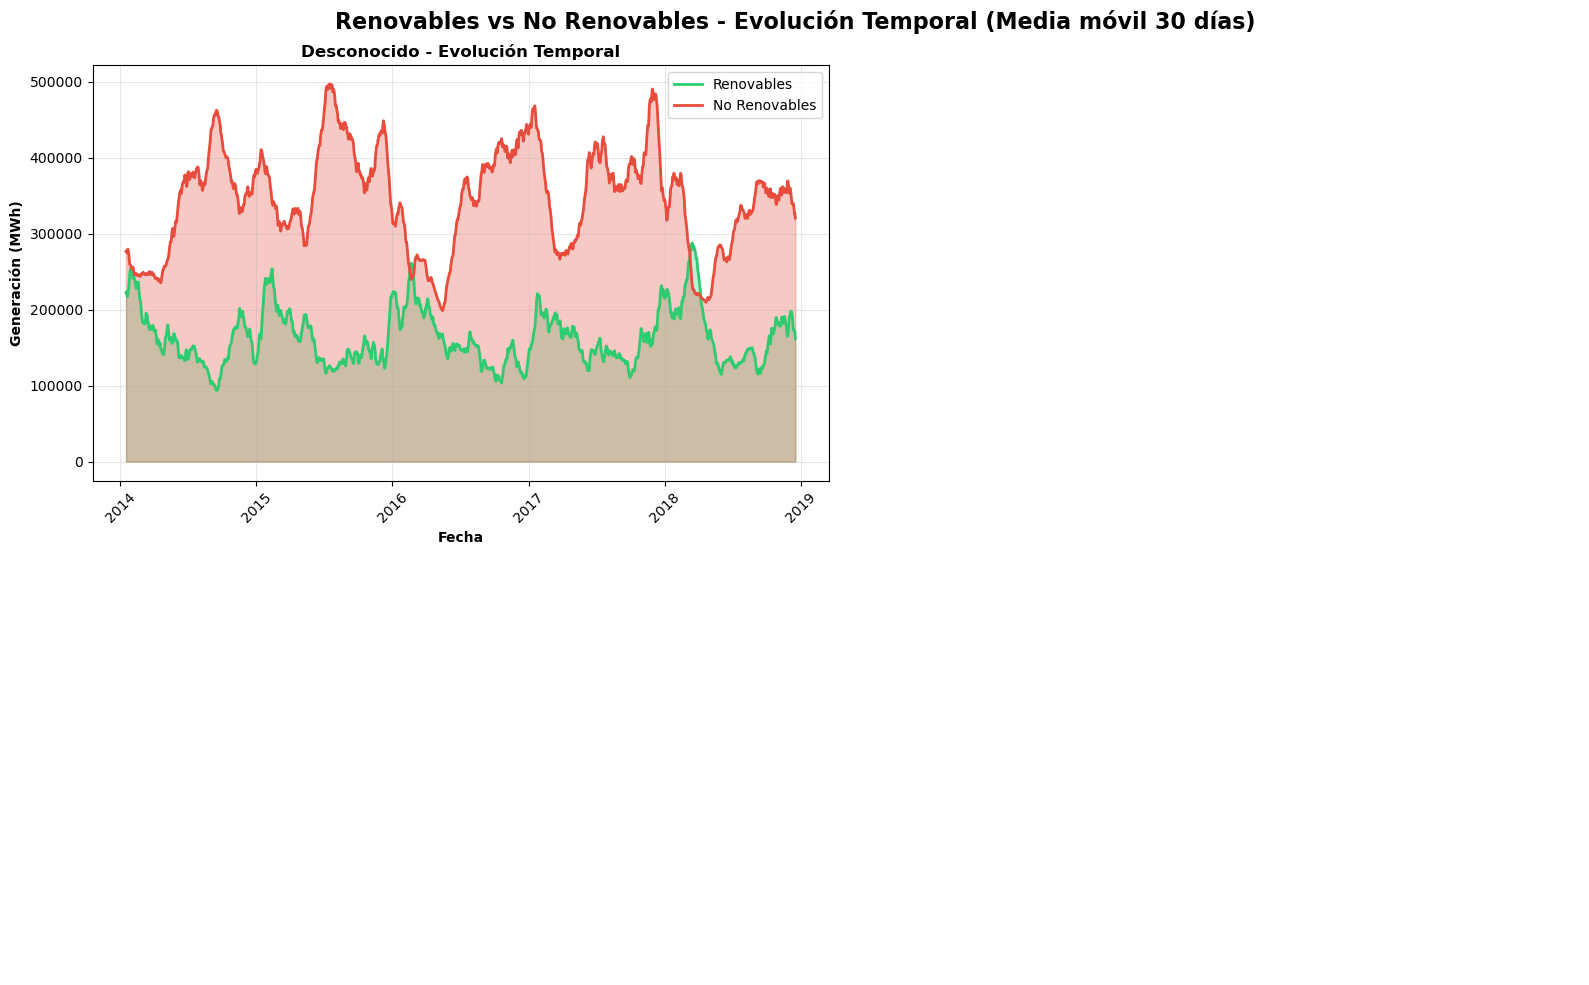


📊 Analizando mix energético por país...


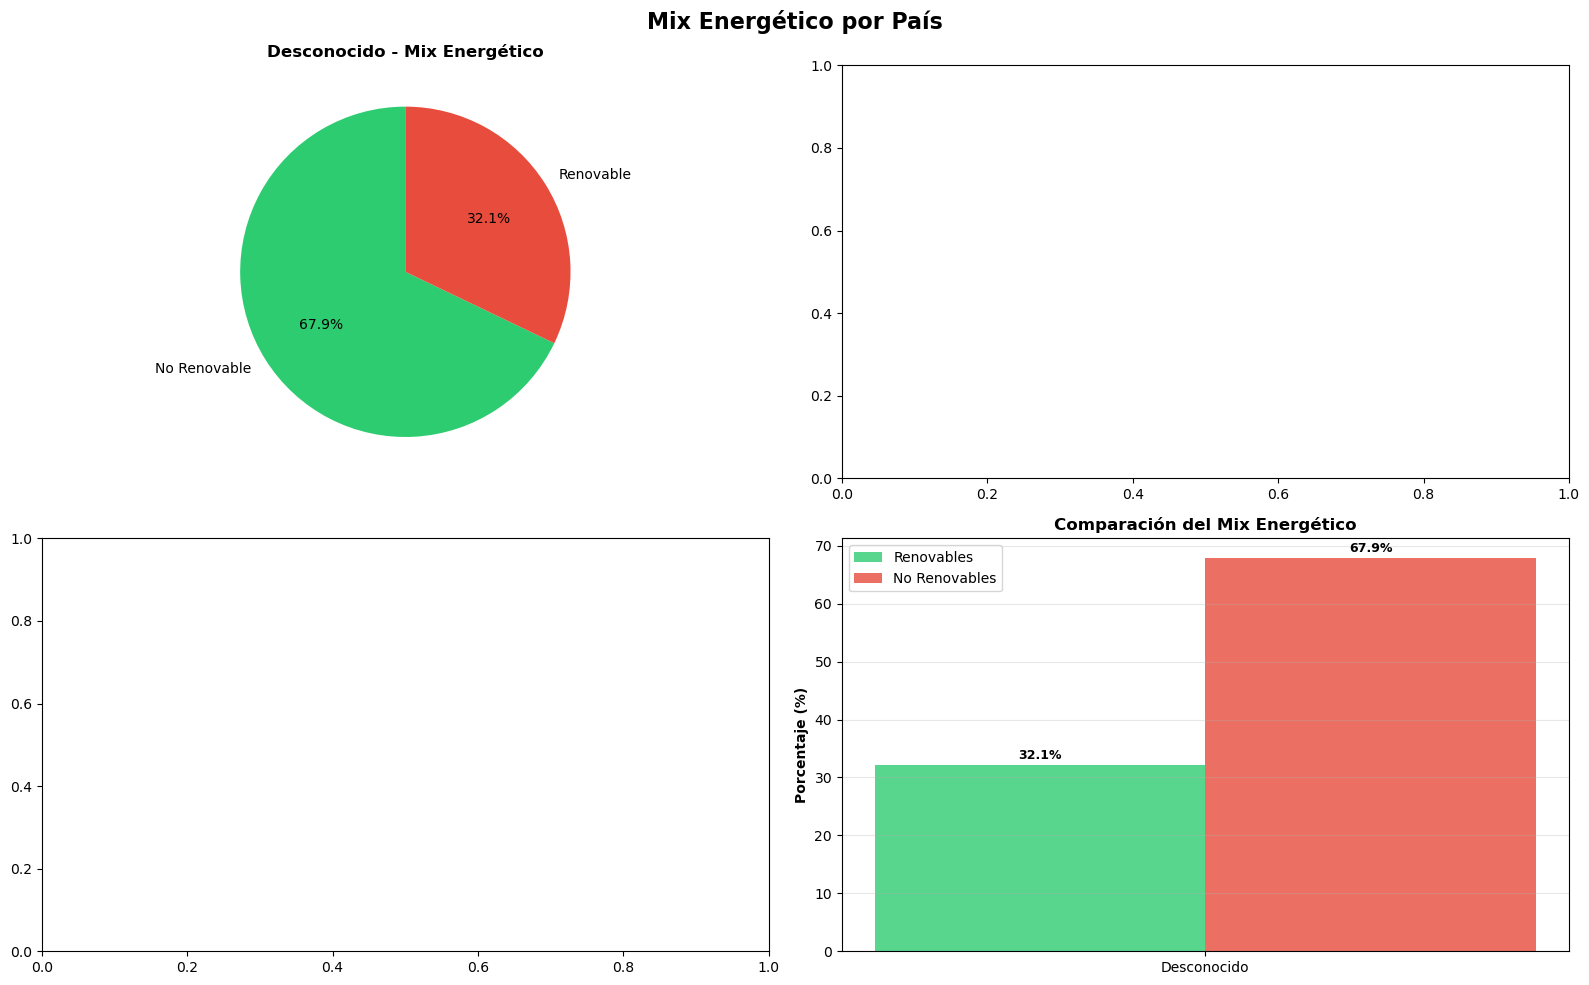


📊 Generando desglose detallado por fuente...


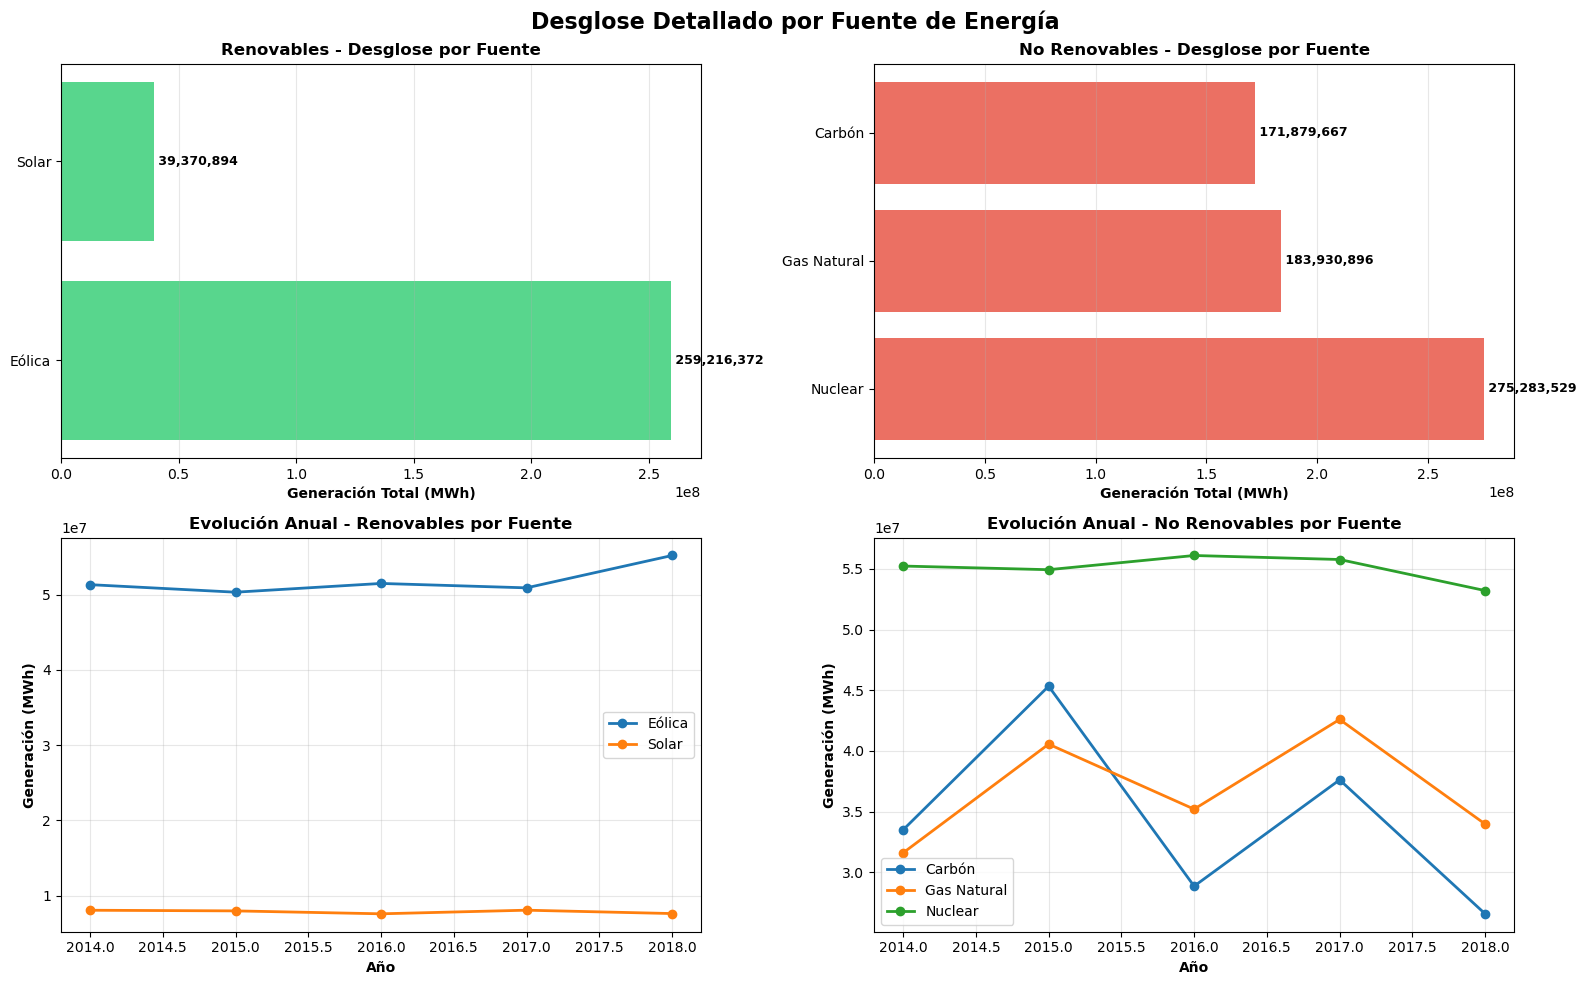


📊 Analizando patrones temporales...


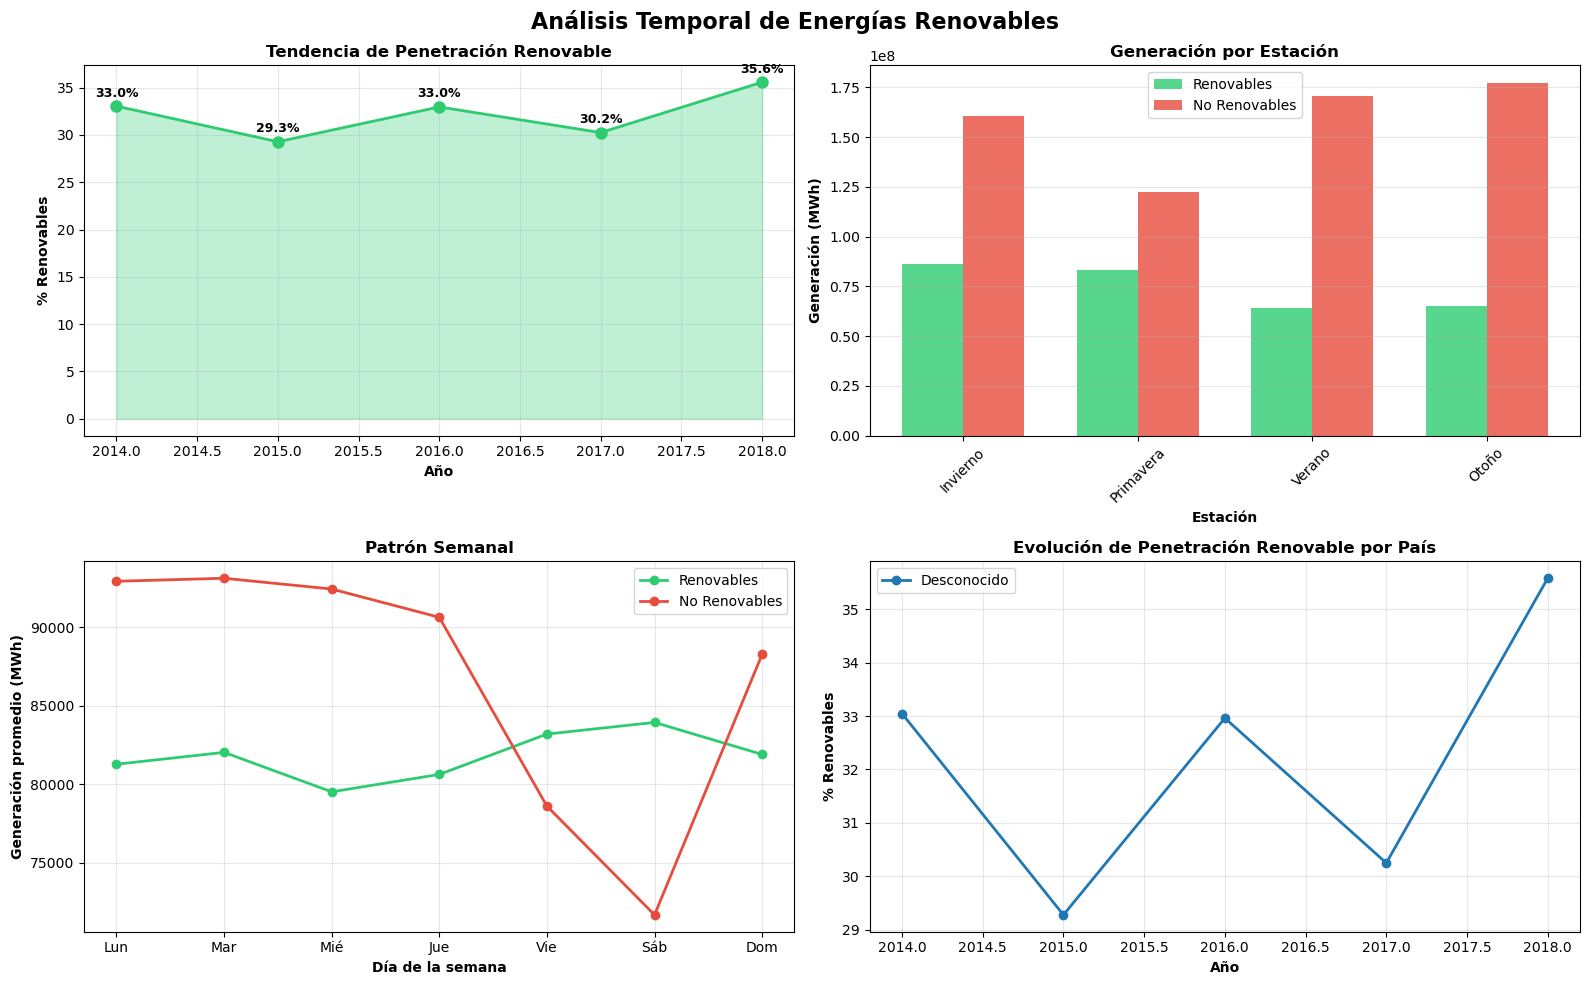


✅ Análisis completo finalizado!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================
# 1. CLASIFICACIÓN DE FUENTES DE ENERGÍA
# ============================================
def clasificar_fuente_energia(name):
    """
    Clasifica las fuentes de energía en renovables, no renovables, u otros
    """
    if pd.isna(name):
        return 'Otros', 'Otros'

    name_lower = name.lower()

    # RENOVABLES
    if any(palabra in name_lower for palabra in ['eólica', 'eolica', 'wind']):
        return 'Renovable', 'Eólica'

    if any(palabra in name_lower for palabra in ['solar', 'fotovoltaica', 'photovoltaic']):
        return 'Renovable', 'Solar'

    if any(palabra in name_lower for palabra in ['hidráulica', 'hidraulica', 'hydraulic', 'hydro']):
        return 'Renovable', 'Hidráulica'

    if any(palabra in name_lower for palabra in ['biomasa', 'biomass']):
        return 'Renovable', 'Biomasa'

    if any(palabra in name_lower for palabra in ['geotérmica', 'geotermica', 'geothermal']):
        return 'Renovable', 'Geotérmica'

    if any(palabra in name_lower for palabra in ['mareomotriz', 'tidal', 'undimotriz', 'wave']):
        return 'Renovable', 'Marina'

    # NO RENOVABLES
    if any(palabra in name_lower for palabra in ['nuclear', 'nucleaire']):
        return 'No Renovable', 'Nuclear'

    if any(palabra in name_lower for palabra in ['carbón', 'carbon', 'coal', 'hulla']):
        return 'No Renovable', 'Carbón'

    if any(palabra in name_lower for palabra in ['gas', 'ciclo combinado', 'combined cycle']):
        return 'No Renovable', 'Gas Natural'

    if any(palabra in name_lower for palabra in ['fuel', 'gasoil', 'diesel', 'petróleo', 'petroleo']):
        return 'No Renovable', 'Petróleo/Fuel'

    if any(palabra in name_lower for palabra in ['cogeneración', 'cogeneration', 'cogen']):
        return 'No Renovable', 'Cogeneración'

    # OTROS (totales, comercio, etc.)
    if any(palabra in name_lower for palabra in ['total', 'precio', 'demanda', 'comercio',
                                                   'asignada', 'programada', 'renta']):
        return 'Otros', 'Otros'

    return 'Otros', 'No clasificado'


def preparar_datos_energia(df):
    """
    Prepara el dataset clasificando fuentes de energía
    """
    df = df.copy()

    # Clasificar cada registro
    df[['tipo_energia', 'fuente_especifica']] = df['name'].apply(
        lambda x: pd.Series(clasificar_fuente_energia(x))
    )

    # Asegurar datetime
    if not pd.api.types.is_datetime64_any_dtype(df['datetime']):
        df['datetime'] = pd.to_datetime(df['datetime'])

    df['year'] = df['datetime'].dt.year
    df['mes'] = df['datetime'].dt.month
    df['fecha'] = df['datetime'].dt.date

    # Filtrar solo datos de generación (excluir precios, comercio, etc.)
    df_energia = df[df['tipo_energia'].isin(['Renovable', 'No Renovable'])].copy()

    print("=" * 80)
    print("CLASIFICACIÓN DE FUENTES DE ENERGÍA")
    print("=" * 80)
    print(f"\nTotal de registros de energía: {len(df_energia):,}")
    print(f"\nDistribución por tipo:")
    print(df_energia['tipo_energia'].value_counts())
    print(f"\nFuentes renovables encontradas:")
    print(df_energia[df_energia['tipo_energia'] == 'Renovable']['fuente_especifica'].value_counts())
    print(f"\nFuentes no renovables encontradas:")
    print(df_energia[df_energia['tipo_energia'] == 'No Renovable']['fuente_especifica'].value_counts())

    return df_energia


# ============================================
# 2. COMPARACIÓN RENOVABLES VS NO RENOVABLES
# ============================================
def grafico_renovables_vs_no_renovables(df_energia):
    """
    Gráfico de evolución temporal renovables vs no renovables
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    paises = sorted(df_energia['geoname'].unique())

    for idx, pais in enumerate(paises):
        if idx >= 4:  # Solo 4 subplots
            break

        df_pais = df_energia[df_energia['geoname'] == pais]

        # Agregar por fecha y tipo
        daily = df_pais.groupby(['fecha', 'tipo_energia'])['value'].sum().reset_index()
        daily['fecha'] = pd.to_datetime(daily['fecha'])

        # Pivotar para tener columnas por tipo
        pivot = daily.pivot_table(values='value', index='fecha',
                                  columns='tipo_energia', aggfunc='sum', fill_value=0)

        # Suavizar con rolling mean
        pivot_smooth = pivot.rolling(window=30, center=True).mean()

        ax = axes[idx // 2, idx % 2]

        if 'Renovable' in pivot_smooth.columns:
            ax.plot(pivot_smooth.index, pivot_smooth['Renovable'],
                   label='Renovables', linewidth=2, color='#2ecc71')
            ax.fill_between(pivot_smooth.index, 0, pivot_smooth['Renovable'],
                          alpha=0.3, color='#2ecc71')

        if 'No Renovable' in pivot_smooth.columns:
            ax.plot(pivot_smooth.index, pivot_smooth['No Renovable'],
                   label='No Renovables', linewidth=2, color='#e74c3c')
            ax.fill_between(pivot_smooth.index, 0, pivot_smooth['No Renovable'],
                          alpha=0.3, color='#e74c3c')

        ax.set_xlabel('Fecha', fontweight='bold')
        ax.set_ylabel('Generación (MWh)', fontweight='bold')
        ax.set_title(f'{pais} - Evolución Temporal', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)

    # Si quedan subplots vacíos, ocultarlos
    for idx in range(len(paises), 4):
        axes[idx // 2, idx % 2].axis('off')

    plt.suptitle('Renovables vs No Renovables - Evolución Temporal (Media móvil 30 días)',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================
# 3. PROPORCIÓN Y MIX ENERGÉTICO
# ============================================
def mix_energetico_por_pais(df_energia):
    """
    Muestra la proporción del mix energético por país
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    paises = sorted(df_energia['geoname'].unique())

    # 1. Pie charts por país
    for idx, pais in enumerate(paises[:3]):  # Máximo 3 países
        df_pais = df_energia[df_energia['geoname'] == pais]

        # Total por tipo
        totales = df_pais.groupby('tipo_energia')['value'].sum()

        ax = axes[idx // 2, idx % 2]
        colors = ['#2ecc71', '#e74c3c']
        ax.pie(totales.values, labels=totales.index, autopct='%1.1f%%',
              colors=colors, startangle=90)
        ax.set_title(f'{pais} - Mix Energético', fontweight='bold')

    # 2. Comparación entre países (barras)
    ax = axes[1, 1]

    data_comparacion = []
    for pais in paises:
        df_pais = df_energia[df_energia['geoname'] == pais]
        total_renovable = df_pais[df_pais['tipo_energia'] == 'Renovable']['value'].sum()
        total_no_renovable = df_pais[df_pais['tipo_energia'] == 'No Renovable']['value'].sum()
        total = total_renovable + total_no_renovable

        if total > 0:
            pct_renovable = (total_renovable / total) * 100
            pct_no_renovable = (total_no_renovable / total) * 100

            data_comparacion.append({
                'País': pais,
                'Renovables': pct_renovable,
                'No Renovables': pct_no_renovable
            })

    df_comp = pd.DataFrame(data_comparacion)

    x = np.arange(len(df_comp))
    width = 0.35

    ax.bar(x - width/2, df_comp['Renovables'], width,
          label='Renovables', color='#2ecc71', alpha=0.8)
    ax.bar(x + width/2, df_comp['No Renovables'], width,
          label='No Renovables', color='#e74c3c', alpha=0.8)

    ax.set_ylabel('Porcentaje (%)', fontweight='bold')
    ax.set_title('Comparación del Mix Energético', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_comp['País'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Añadir valores
    for i, row in df_comp.iterrows():
        ax.text(i - width/2, row['Renovables'] + 1, f"{row['Renovables']:.1f}%",
               ha='center', fontweight='bold', fontsize=9)
        ax.text(i + width/2, row['No Renovables'] + 1, f"{row['No Renovables']:.1f}%",
               ha='center', fontweight='bold', fontsize=9)

    plt.suptitle('Mix Energético por País', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================
# 4. DESGLOSE POR FUENTE ESPECÍFICA
# ============================================
def desglose_fuentes_especificas(df_energia):
    """
    Análisis detallado de cada fuente de energía
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1. Renovables - desglose por fuente
    df_renovables = df_energia[df_energia['tipo_energia'] == 'Renovable']
    fuentes_ren = df_renovables.groupby('fuente_especifica')['value'].sum().sort_values(ascending=False)

    if len(fuentes_ren) > 0:
        axes[0, 0].barh(fuentes_ren.index, fuentes_ren.values, color='#2ecc71', alpha=0.8)
        axes[0, 0].set_xlabel('Generación Total (MWh)', fontweight='bold')
        axes[0, 0].set_title('Renovables - Desglose por Fuente', fontweight='bold')
        axes[0, 0].grid(axis='x', alpha=0.3)

        for i, v in enumerate(fuentes_ren.values):
            axes[0, 0].text(v, i, f' {v:,.0f}', va='center', fontweight='bold', fontsize=9)

    # 2. No Renovables - desglose por fuente
    df_no_renovables = df_energia[df_energia['tipo_energia'] == 'No Renovable']
    fuentes_no_ren = df_no_renovables.groupby('fuente_especifica')['value'].sum().sort_values(ascending=False)

    if len(fuentes_no_ren) > 0:
        axes[0, 1].barh(fuentes_no_ren.index, fuentes_no_ren.values, color='#e74c3c', alpha=0.8)
        axes[0, 1].set_xlabel('Generación Total (MWh)', fontweight='bold')
        axes[0, 1].set_title('No Renovables - Desglose por Fuente', fontweight='bold')
        axes[0, 1].grid(axis='x', alpha=0.3)

        for i, v in enumerate(fuentes_no_ren.values):
            axes[0, 1].text(v, i, f' {v:,.0f}', va='center', fontweight='bold', fontsize=9)

    # 3. Evolución anual de renovables por fuente
    yearly_ren = df_renovables.groupby(['year', 'fuente_especifica'])['value'].sum().reset_index()

    for fuente in yearly_ren['fuente_especifica'].unique():
        df_fuente = yearly_ren[yearly_ren['fuente_especifica'] == fuente]
        axes[1, 0].plot(df_fuente['year'], df_fuente['value'],
                       marker='o', label=fuente, linewidth=2)

    axes[1, 0].set_xlabel('Año', fontweight='bold')
    axes[1, 0].set_ylabel('Generación (MWh)', fontweight='bold')
    axes[1, 0].set_title('Evolución Anual - Renovables por Fuente', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Evolución anual de no renovables por fuente
    yearly_no_ren = df_no_renovables.groupby(['year', 'fuente_especifica'])['value'].sum().reset_index()

    for fuente in yearly_no_ren['fuente_especifica'].unique():
        df_fuente = yearly_no_ren[yearly_no_ren['fuente_especifica'] == fuente]
        axes[1, 1].plot(df_fuente['year'], df_fuente['value'],
                       marker='o', label=fuente, linewidth=2)

    axes[1, 1].set_xlabel('Año', fontweight='bold')
    axes[1, 1].set_ylabel('Generación (MWh)', fontweight='bold')
    axes[1, 1].set_title('Evolución Anual - No Renovables por Fuente', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('Desglose Detallado por Fuente de Energía', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================
# 5. ANÁLISIS TEMPORAL AVANZADO
# ============================================
def analisis_temporal_renovables(df_energia):
    """
    Análisis de patrones temporales en el uso de renovables
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Agregar features temporales
    def get_estacion(mes):
        if mes in [12, 1, 2]:
            return 'Invierno'
        elif mes in [3, 4, 5]:
            return 'Primavera'
        elif mes in [6, 7, 8]:
            return 'Verano'
        else:
            return 'Otoño'

    df_energia['estacion'] = df_energia['mes'].apply(get_estacion)
    df_energia['dia_semana'] = df_energia['datetime'].dt.dayofweek
    df_energia['es_fin_semana'] = df_energia['dia_semana'].isin([5, 6])

    # 1. Porcentaje renovable por año
    yearly_pct = []
    for year in df_energia['year'].unique():
        df_year = df_energia[df_energia['year'] == year]
        ren = df_year[df_year['tipo_energia'] == 'Renovable']['value'].sum()
        no_ren = df_year[df_year['tipo_energia'] == 'No Renovable']['value'].sum()
        total = ren + no_ren
        if total > 0:
            yearly_pct.append({'year': year, 'pct_renovable': (ren / total) * 100})

    df_yearly_pct = pd.DataFrame(yearly_pct)

    axes[0, 0].plot(df_yearly_pct['year'], df_yearly_pct['pct_renovable'],
                   marker='o', linewidth=2, markersize=8, color='#2ecc71')
    axes[0, 0].fill_between(df_yearly_pct['year'], 0, df_yearly_pct['pct_renovable'],
                           alpha=0.3, color='#2ecc71')
    axes[0, 0].set_xlabel('Año', fontweight='bold')
    axes[0, 0].set_ylabel('% Renovables', fontweight='bold')
    axes[0, 0].set_title('Tendencia de Penetración Renovable', fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)

    # Añadir valores
    for _, row in df_yearly_pct.iterrows():
        axes[0, 0].text(row['year'], row['pct_renovable'] + 1,
                       f"{row['pct_renovable']:.1f}%",
                       ha='center', fontweight='bold', fontsize=9)

    # 2. Estacionalidad de renovables
    seasonal = df_energia.groupby(['estacion', 'tipo_energia'])['value'].sum().reset_index()
    seasonal_pivot = seasonal.pivot(index='estacion', columns='tipo_energia', values='value')
    seasonal_pivot = seasonal_pivot.reindex(['Invierno', 'Primavera', 'Verano', 'Otoño'])

    x = np.arange(len(seasonal_pivot))
    width = 0.35

    if 'Renovable' in seasonal_pivot.columns:
        axes[0, 1].bar(x - width/2, seasonal_pivot['Renovable'], width,
                      label='Renovables', color='#2ecc71', alpha=0.8)
    if 'No Renovable' in seasonal_pivot.columns:
        axes[0, 1].bar(x + width/2, seasonal_pivot['No Renovable'], width,
                      label='No Renovables', color='#e74c3c', alpha=0.8)

    axes[0, 1].set_xlabel('Estación', fontweight='bold')
    axes[0, 1].set_ylabel('Generación (MWh)', fontweight='bold')
    axes[0, 1].set_title('Generación por Estación', fontweight='bold')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(seasonal_pivot.index)
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    axes[0, 1].tick_params(axis='x', rotation=45)

    # 3. Patrón semanal
    weekly = df_energia.groupby(['dia_semana', 'tipo_energia'])['value'].mean().reset_index()
    weekly_pivot = weekly.pivot(index='dia_semana', columns='tipo_energia', values='value')

    dias_nombres = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

    if 'Renovable' in weekly_pivot.columns:
        axes[1, 0].plot(range(7), weekly_pivot['Renovable'],
                       marker='o', label='Renovables', linewidth=2, color='#2ecc71')
    if 'No Renovable' in weekly_pivot.columns:
        axes[1, 0].plot(range(7), weekly_pivot['No Renovable'],
                       marker='o', label='No Renovables', linewidth=2, color='#e74c3c')

    axes[1, 0].set_xlabel('Día de la semana', fontweight='bold')
    axes[1, 0].set_ylabel('Generación promedio (MWh)', fontweight='bold')
    axes[1, 0].set_title('Patrón Semanal', fontweight='bold')
    axes[1, 0].set_xticks(range(7))
    axes[1, 0].set_xticklabels(dias_nombres)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Porcentaje renovable por país y año
    country_year_pct = []
    for pais in df_energia['geoname'].unique():
        for year in df_energia['year'].unique():
            df_subset = df_energia[(df_energia['geoname'] == pais) & (df_energia['year'] == year)]
            ren = df_subset[df_subset['tipo_energia'] == 'Renovable']['value'].sum()
            no_ren = df_subset[df_subset['tipo_energia'] == 'No Renovable']['value'].sum()
            total = ren + no_ren
            if total > 0:
                country_year_pct.append({
                    'pais': pais,
                    'year': year,
                    'pct_renovable': (ren / total) * 100
                })

    df_country_year = pd.DataFrame(country_year_pct)

    for pais in df_country_year['pais'].unique():
        df_pais = df_country_year[df_country_year['pais'] == pais]
        axes[1, 1].plot(df_pais['year'], df_pais['pct_renovable'],
                       marker='o', label=pais, linewidth=2)

    axes[1, 1].set_xlabel('Año', fontweight='bold')
    axes[1, 1].set_ylabel('% Renovables', fontweight='bold')
    axes[1, 1].set_title('Evolución de Penetración Renovable por País', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle('Análisis Temporal de Energías Renovables', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ============================================
# 6. DASHBOARD COMPLETO RENOVABLES
# ============================================
def dashboard_renovables_completo(df):
    """
    Dashboard completo con todos los análisis de renovables
    """
    print("\n" + "="*80)
    print("ANÁLISIS COMPLETO DE ENERGÍAS RENOVABLES VS NO RENOVABLES")
    print("="*80 + "\n")

    # 1. Preparar datos
    print("📊 Preparando y clasificando fuentes de energía...")
    df_energia = preparar_datos_energia(df)

    # 2. Comparación general
    print("\n📊 Generando comparación renovables vs no renovables...")
    grafico_renovables_vs_no_renovables(df_energia)

    # 3. Mix energético
    print("\n📊 Analizando mix energético por país...")
    mix_energetico_por_pais(df_energia)

    # 4. Desglose por fuentes
    print("\n📊 Generando desglose detallado por fuente...")
    desglose_fuentes_especificas(df_energia)

    # 5. Análisis temporal
    print("\n📊 Analizando patrones temporales...")
    analisis_temporal_renovables(df_energia)

    print("\n✅ Análisis completo finalizado!")

    return df_energia


# ============================================
# EJEMPLO DE USO
# ============================================

# Opción 1: Dashboard completo (recomendado)
df_energia = dashboard_renovables_completo(df)



In [ ]:
print(df_energia.head())

                 datetime     id                              name  \
25644 2014-01-01 23:00:00  10073  Generación programada PBF Eólica   
25645 2014-01-02 23:00:00  10073  Generación programada PBF Eólica   
25646 2014-01-03 23:00:00  10073  Generación programada PBF Eólica   
25647 2014-01-04 23:00:00  10073  Generación programada PBF Eólica   
25648 2014-01-05 23:00:00  10073  Generación programada PBF Eólica   

             geoid      geoname     value        date      time  year  \
25644  Desconocido  Desconocido  277443.9  2014-01-01  23:00:00  2014   
25645  Desconocido  Desconocido  237323.1  2014-01-02  23:00:00  2014   
25646  Desconocido  Desconocido  329506.6  2014-01-03  23:00:00  2014   
25647  Desconocido  Desconocido  292138.3  2014-01-04  23:00:00  2014   
25648  Desconocido  Desconocido  223942.0  2014-01-05  23:00:00  2014   

                   categoria tipo_energia fuente_especifica  mes       fecha  \
25644  Generación por fuente    Renovable            Eólica 